In [1]:
import pandas as pd
import numpy as np
import os
import json
os.makedirs("output", exist_ok=True)
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV, RandomizedSearchCV, HalvingRandomSearchCV,cross_val_score, KFold
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score, mean_absolute_percentage_error
from mapie.regression import MapieRegressor
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, kpss
from datetime import timedelta, datetime

import optuna
from shap import TreeExplainer, summary_plot, dependence_plot, Explainer, LinearExplainer

from scipy.optimize import minimize
from sklearn.base import BaseEstimator, RegressorMixin

pd.set_option("display.max_rows", None)
#pd.reset_option("display.max_rows")

## Data Exploring and Preprocessing

In [2]:
# Load data
file_path = "input/Ventas_2022-2024_ALL_RC_FINAL.xlsx"
df = pd.read_excel(file_path, sheet_name="Sheet1", parse_dates=["Date"])
file_path_dim = "input/Dimensão_Produto.xlsx"
df_dim = pd.read_excel(file_path_dim, sheet_name="Sheet1")

#open output_concatenated_daily.csv
#df_org = pd.read_csv("input/output_concatenated_daily.csv", parse_dates=["date"])

In [3]:
#Print start and end date
print(df["Date"].min())
print(df["Date"].max())

#see if there is any missing date in the date range
date_range = pd.date_range(start=df["Date"].min(), end=df["Date"].max())
missing_dates = date_range.difference(df["Date"])
print(missing_dates)

2022-09-15 00:00:00
2024-12-10 00:00:00
DatetimeIndex([], dtype='datetime64[ns]', freq='D')


In [4]:
""" missing_dates = pd.DatetimeIndex([
    "2024-01-20",
    "2024-01-22",
    "2024-01-23",
    "2024-07-28",
    "2024-10-26",
    "2025-04-28"
])

new_rows = []

for missing_date in missing_dates:
    previous_date = missing_date - pd.Timedelta(days=1)

    rows_to_copy = df_org[df_org["date"] == previous_date].copy()

    if rows_to_copy.empty:
        print(f"No previous day found for {missing_date}")
        continue

    rows_to_copy["date"] = missing_date
    new_rows.append(rows_to_copy)

df_org_filled = pd.concat([df_org] + new_rows, ignore_index=True)
df_org_filled = df_org_filled.sort_values("date").reset_index(drop=True)

df_org_filled.to_csv("input/output_concatenated_daily_filled.csv", index=False)

print("Filled isolated missing dates only.") """

' missing_dates = pd.DatetimeIndex([\n    "2024-01-20",\n    "2024-01-22",\n    "2024-01-23",\n    "2024-07-28",\n    "2024-10-26",\n    "2025-04-28"\n])\n\nnew_rows = []\n\nfor missing_date in missing_dates:\n    previous_date = missing_date - pd.Timedelta(days=1)\n\n    rows_to_copy = df_org[df_org["date"] == previous_date].copy()\n\n    if rows_to_copy.empty:\n        print(f"No previous day found for {missing_date}")\n        continue\n\n    rows_to_copy["date"] = missing_date\n    new_rows.append(rows_to_copy)\n\ndf_org_filled = pd.concat([df_org] + new_rows, ignore_index=True)\ndf_org_filled = df_org_filled.sort_values("date").reset_index(drop=True)\n\ndf_org_filled.to_csv("input/output_concatenated_daily_filled.csv", index=False)\n\nprint("Filled isolated missing dates only.") '

In [5]:
""" missing_dates = pd.DatetimeIndex([

    "2024-01-23",
])

new_rows = []

for missing_date in missing_dates:
    previous_date = missing_date - pd.Timedelta(days=1)

    rows_to_copy = df_org_filled[df_org_filled["date"] == previous_date].copy()

    if rows_to_copy.empty:
        print(f"No previous day found for {missing_date}")
        continue

    rows_to_copy["date"] = missing_date
    new_rows.append(rows_to_copy)

df_org_filled = pd.concat([df_org_filled] + new_rows, ignore_index=True)
df_org_filled = df_org_filled.sort_values("date").reset_index(drop=True)

df_org_filled.to_csv("input/output_concatenated_daily_filled.csv", index=False)

print("Filled isolated missing dates only.") """

' missing_dates = pd.DatetimeIndex([\n\n    "2024-01-23",\n])\n\nnew_rows = []\n\nfor missing_date in missing_dates:\n    previous_date = missing_date - pd.Timedelta(days=1)\n\n    rows_to_copy = df_org_filled[df_org_filled["date"] == previous_date].copy()\n\n    if rows_to_copy.empty:\n        print(f"No previous day found for {missing_date}")\n        continue\n\n    rows_to_copy["date"] = missing_date\n    new_rows.append(rows_to_copy)\n\ndf_org_filled = pd.concat([df_org_filled] + new_rows, ignore_index=True)\ndf_org_filled = df_org_filled.sort_values("date").reset_index(drop=True)\n\ndf_org_filled.to_csv("input/output_concatenated_daily_filled.csv", index=False)\n\nprint("Filled isolated missing dates only.") '

In [6]:
""" #see if there is any missing date in the date range
date_range = pd.date_range(start=df_org["date"].min(), end=df_org["date"].max())
missing_dates = date_range.difference(df_org["date"])
print(missing_dates) """

' #see if there is any missing date in the date range\ndate_range = pd.date_range(start=df_org["date"].min(), end=df_org["date"].max())\nmissing_dates = date_range.difference(df_org["date"])\nprint(missing_dates) '

In [7]:
""" #see if there is any missing date in the date range
date_range = pd.date_range(start=df["Date"].min(), end=df["Date"].max())
missing_dates = date_range.difference(df["Date"])
print(missing_dates) """

' #see if there is any missing date in the date range\ndate_range = pd.date_range(start=df["Date"].min(), end=df["Date"].max())\nmissing_dates = date_range.difference(df["Date"])\nprint(missing_dates) '

In [8]:
print(df.columns)
df.info()

Index(['Date', 'ProductId', 'SKU', 'Name', 'Brand', 'Model',
       'Tipo de producto', 'Cod. PLU', 'Quantity', 'Flag Card', 'Brand-Model',
       'Value', 'Price Mademsa', 'Price Rheem', 'Price Splendid',
       'Price_Sindelen', 'Price (UN)', 'Store Name', 'Price_Anwo',
       'Normal Price', 'Flag Return', 'Flag OUT_OF_STOCK'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 79638 entries, 0 to 79637
Data columns (total 22 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Date               79638 non-null  datetime64[ns]
 1   ProductId          79638 non-null  int64         
 2   SKU                79638 non-null  object        
 3   Name               79638 non-null  object        
 4   Brand              79638 non-null  object        
 5   Model              79638 non-null  object        
 6   Tipo de producto   79638 non-null  object        
 7   Cod. PLU           79638 non-null  i

In [9]:
print(df_dim.columns)
df_dim.info()

Index(['ProductId', 'Name', 'Brand', 'Model', 'Tipo de producto',
       'Tipo de combustible', 'Capacidad por minuto', 'Capacidad por volumen',
       'Calefones Tiro Natural', 'Capacidad', 'ProductId&SKU',
       'ProductId&SKU&StoreName'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 484 entries, 0 to 483
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   ProductId                484 non-null    int64 
 1   Name                     484 non-null    object
 2   Brand                    484 non-null    object
 3   Model                    484 non-null    object
 4   Tipo de producto         484 non-null    object
 5   Tipo de combustible      484 non-null    object
 6   Capacidad por minuto     484 non-null    int64 
 7   Capacidad por volumen    484 non-null    int64 
 8   Calefones Tiro Natural   484 non-null    bool  
 9   Capacidad                484 non-null    i

In [10]:
print(len(df))

79638


In [11]:
# new section
df = df[df["Date"] < "2024-12-09"]


#Print start and end date
print(df["Date"].min())
print(df["Date"].max())

2022-09-15 00:00:00
2024-12-08 00:00:00


In [12]:
print(len(df))

79490


In [13]:
print(df["Store Name"].unique())

['Sodimac' 'Easy']


In [14]:
# Show Unique values of "Tipo de producto"
print(df["Tipo de producto"].unique())

['Calefont' 'Termo' 'Caldera']


In [15]:
#sum col "value"
print(df["Value"].sum())
#sum col "Quantity"
print(df["Quantity"].sum())
#average Col "Price (UN)"
print(df["Price (UN)"].mean())

#mean and var of "Quantity"
print(df["Quantity"].mean())
print(df["Quantity"].var())

55518181573
254182
415402.1163794188
3.197660083029312
126.49388424530996


In [16]:
#remove duplicates from df_dim based on ProductId
df_dim = df_dim.drop_duplicates(subset=["ProductId"])

#filter df_dim by brand "Bosch", "Junkers" and "Neckar"
#df_dim = df_dim[df_dim["Brand"].isin(["Bosch", "Junkers", "Neckar"])]

# Remove blank ProductId rows
df_dim = df_dim[df_dim["ProductId"].notna() & (df_dim["ProductId"].astype(str).str.strip() != "")]

# merge df with cols Tipo de combustible, Capacidad por minuto, Capacidad por volumen, Calefones Tiro Natural, Capacidad from df_dim on df_dim.ProductId  = df.ProductId
df = df.merge(df_dim[["ProductId", "Tipo de combustible", "Capacidad por minuto", "Capacidad por volumen", "Calefones Tiro Natural", "Capacidad"]], on="ProductId",how="left", validate="many_to_one")
#df.drop("ProductId", axis=1, inplace=True)

In [17]:
print(len(df))

79490


In [18]:
df.columns

Index(['Date', 'ProductId', 'SKU', 'Name', 'Brand', 'Model',
       'Tipo de producto', 'Cod. PLU', 'Quantity', 'Flag Card', 'Brand-Model',
       'Value', 'Price Mademsa', 'Price Rheem', 'Price Splendid',
       'Price_Sindelen', 'Price (UN)', 'Store Name', 'Price_Anwo',
       'Normal Price', 'Flag Return', 'Flag OUT_OF_STOCK',
       'Tipo de combustible', 'Capacidad por minuto', 'Capacidad por volumen',
       'Calefones Tiro Natural', 'Capacidad'],
      dtype='object')

In [19]:
#print unique values in col Capacidad
print(df["Capacidad"].unique())

[ 15  24  80 120  50 100 150   7  16  18  21  12  30  11  75  17   5  19
  14  13  10   8]


In [20]:
print(df["Capacidad por volumen"].unique())

[ -1  80 120  50 100 150  30  75]


In [21]:
print(df["Capacidad por minuto"].unique())
#order by ascending Capacidad por minuto
df = df.sort_values(by="Capacidad por minuto", ascending=True)

[15 24 -1  7 16 18 21 12 11 17  5 19 14 13 10  8]


Plot saved to output/Thesis/Monthly_seasonal_decompose.png


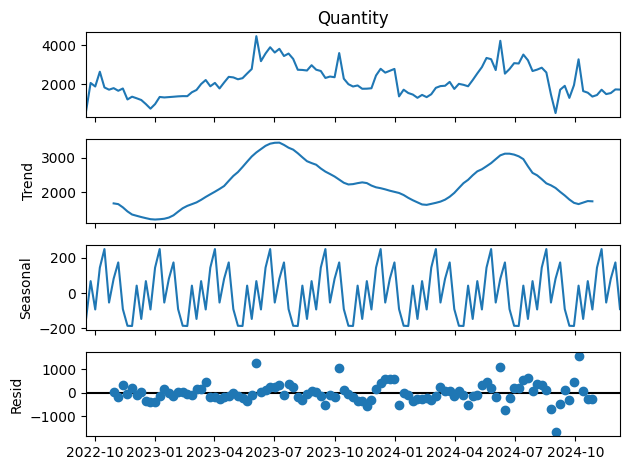

In [22]:
#order by Date ascending
df.sort_values(by=["Date"], inplace=True)


df_temp = df.copy()
# Set 'Date' as the index
df_temp.set_index("Date", inplace=True)
# Resample to monthly frequency (summing 'Quantity')
df_monthly = df_temp["Quantity"].resample("W").sum()
# Decompose the time series with an additive model
result = seasonal_decompose(df_monthly, model='additive', period=12)
result.plot()

current_datetime = datetime.now().strftime("%Y%m%d_%H%M%S")
file_name =f"output/Thesis/Monthly_seasonal_decompose.png"

plt.savefig(file_name, dpi=300, bbox_inches="tight")
print(f"Plot saved to {file_name}")

plt.show()
plt.close()

In [23]:
df.sort_values(by=["Date"], inplace=True)
#date feature engineering
df["dayYear"] = df["Date"].dt.dayofyear
df["dayWeek"] = df["Date"].dt.day_of_week
df["dayMonth"] = df["Date"].dt.day
df["sin_day"] = np.sin(2 * np.pi * df["dayYear"] / 365)
df["cos_day"] = np.cos(2 * np.pi * df["dayYear"] / 365)
df["isoWeek"] = df["Date"].dt.isocalendar().week.astype(int)
df['week_sin'] = np.sin(2*np.pi*(df['isoWeek']-1)/52)
df['week_cos'] = np.cos(2*np.pi*(df['isoWeek']-1)/52)
df["year"] = df["Date"].dt.year
df["month"] = df["Date"].dt.month

#transform Date to ordinal
df["date_ordinal"] = df["Date"].map(pd.Timestamp.toordinal)

def season_label(date):
    md = (date.month, date.day)
    if (md >= (12,21)) or (md < (3,20)):
        return 1 #summer
    if (md >= (3,20)) and (md < (6,21)):
        return 2 #autumn
    if (md >= (6,21)) and (md < (9,21)):
        return 3 #winter
    return 4 #spring

df["seasons"] = df["Date"].apply(season_label).astype(int)

#df["PLU_Label"] = LabelEncoder().fit_transform(df["Cod. PLU"])
df["Seller_Code"] = df["Store Name"].map({"Easy": 0, "Sodimac": 1}).fillna(-1).astype(int)

#Create Product Code
df["Tipo_Producto_Code"] = df["Tipo de producto"].map({
    "Calefont": 0,
    "Termo": 1,
    "Caldera": 2
})

#Create Tipo de combustible code
df["Tipo_Combustible_Code"] = df["Tipo de combustible"].map({
    "Gas Natural": 0,
    "Gas Licuado": 1,
    "Eléctrico": 2,
})


In [24]:

# Black Friday dates
bf_dates = pd.to_datetime([
    "2022-11-25",
    "2023-11-24",
    #"2024-11-29"
])

#Cyber Monday (BF + 3 days)
cm_dates = bf_dates + pd.Timedelta(days=0)

# CyberDay Chile
cyberday_dates = pd.to_datetime([
    "2023-05-29",
    "2024-06-03"
])

# Flags (single day)
df["flag_black_friday"] = df["Date"].isin(bf_dates).astype(int)
df["flag_cyber_monday"] = df["Date"].isin(cm_dates).astype(int)
df["flag_cyberday"] = df["Date"].isin(cyberday_dates).astype(int)

# Windows
def create_window_flag(dates, before=0, after=3):
    return (
        df["Date"].isin(dates) |
        df["Date"].isin(dates - pd.Timedelta(days=before)) |
        df["Date"].isin(dates - pd.Timedelta(days=1)) |
        df["Date"].isin(dates + pd.Timedelta(days=1)) |
        df["Date"].isin(dates + pd.Timedelta(days=after))
    ).astype(int)

df["flag_bf_cm_window"] = create_window_flag(bf_dates) | create_window_flag(cm_dates)
df["flag_cyberday_window"] = create_window_flag(cyberday_dates)

# Final combined flag
df["Flag_major_event"] = (
    df["flag_bf_cm_window"] |
    df["flag_cyberday_window"]
).astype(int)

#drop columns "flag_black_friday", "flag_cyber_monday", "flag_cyberday", flag_bf_cm_window, flag_cyberday_window
df.drop(columns=["flag_black_friday", "flag_cyber_monday", "flag_cyberday", "flag_bf_cm_window", "flag_cyberday_window"], inplace=True)


In [25]:
print(len(df))

79490


In [26]:
#new section

#count number of rows that have distinct values in Cod. PLU order ascending
distinct_count = df.groupby(['Cod. PLU']).size().reset_index(name='Count')
distinct_count = distinct_count.sort_values(by='Count', ascending=True)
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    print("Distinct count of Cod. PLU combinations:")
    print(distinct_count)

#distinct_count.to_excel("distinct_cod_plu_count3.xlsx", index=False)

Distinct count of Cod. PLU combinations:
      Cod. PLU  Count
34  7733500031     23
4   7701431027     74
27  7716403070     78
52  7736502712     89
59  7736503218    102
78  7736505308    131
32  7716472634    146
56  7736502723    160
57  7736502724    160
55  7736502722    160
90  7736506598    168
30  7716462947    190
37  7736501834    237
51  7736502711    237
54  7736502714    316
24  7713243819    328
21  7713230753    333
92  7736901269    338
38  7736501835    338
58  7736503216    338
93  7736901271    338
61  7736503347    410
33  7716473644    420
91  7736506599    436
66  7736503358    469
0   7701331004    502
53  7736502713    522
60  7736503346    538
67  7736503360    558
89  7736506597    560
68  7736503375    575
69  7736503377    575
65  7736503357    575
72  7736504599    580
70  7736504597    581
39  7736501836    583
40  7736501837    589
25  7713244799    627
88  7736505615    632
31  7716463938    676
64  7736503353    677
75  7736504602    680
15  770333171

In [27]:
# new section -Keep only products with at least 100 records
df = df.groupby("Cod. PLU").filter(lambda x: len(x) >= 100)

#if Quantity col < 0 then set row to 0
df.loc[df["Quantity"] < 0, "Quantity"] = 0


In [28]:
print(len(df))

79226


In [29]:
#Count Cod. PLU by "Tipo de producto" order descending
print(df.groupby("Tipo de producto")["Cod. PLU"].nunique().sort_values(ascending=False).reset_index(name="Count_PLU"))

df.groupby("Tipo de producto")["Cod. PLU"].nunique().sort_values(ascending=False).reset_index(name="Count_PLU").to_csv("output/Thesis/distinct_cod_plu_count_by_tipo_producto.csv", index=True)

  Tipo de producto  Count_PLU
0         Calefont         60
1            Termo         22
2          Caldera          8


In [30]:
##Count Cod. PLU by grouped by "Tipo de producto" and Capacidad sort by tipo de producto 
print(df.groupby(["Tipo de producto","Tipo de combustible"])["Cod. PLU"].nunique().sort_values(ascending=False).reset_index(name="Count_PLU"))

#save to csv
df.groupby(["Tipo de producto","Tipo de combustible"])["Cod. PLU"].nunique().sort_values(ascending=False).reset_index(name="Count_PLU").to_csv("output/Thesis/distinct_cod_plu_count_by_tipo_producto_combustible.csv", index=True)


  Tipo de producto Tipo de combustible  Count_PLU
0         Calefont         Gas Licuado         31
1         Calefont         Gas Natural         29
2            Termo           Eléctrico         22
3          Caldera         Gas Natural          5
4          Caldera         Gas Licuado          3


In [31]:
##Count Cod. PLU by grouped by "Tipo de producto" and Capacidad sort by tipo de producto 
print(df.groupby(["Tipo de producto", "Capacidad"])["Cod. PLU"].nunique().reset_index(name="Count_PLU"))

#save to csv
df.groupby(["Tipo de producto", "Capacidad"])["Cod. PLU"].nunique().reset_index(name="Count_PLU").to_csv("output/Thesis/distinct_cod_plu_count_by_tipo_producto_capacidad.csv", index=True)

   Tipo de producto  Capacidad  Count_PLU
0           Caldera         14          4
1           Caldera         16          1
2           Caldera         17          2
3           Caldera         19          1
4          Calefont          5          3
5          Calefont          7          7
6          Calefont          8          1
7          Calefont         10          8
8          Calefont         11          6
9          Calefont         12          6
10         Calefont         13          6
11         Calefont         14          6
12         Calefont         15          4
13         Calefont         16          6
14         Calefont         18          4
15         Calefont         21          2
16         Calefont         24          2
17            Termo         30          2
18            Termo         50          4
19            Termo         75          2
20            Termo         80          2
21            Termo        100          5
22            Termo        120    

In [32]:
##Count Cod. PLU by grouped by "Tipo de producto" and Capacidad sort by tipo de producto 
print(df.groupby(["Tipo de producto","Tipo de combustible", "Capacidad"])["Cod. PLU"].nunique().sort_values(ascending=False).reset_index(name="Count_PLU"))

#save to csv
df.groupby(["Tipo de producto","Tipo de combustible", "Capacidad"])["Cod. PLU"].nunique().sort_values(ascending=False).reset_index(name="Count_PLU").to_csv("output/Thesis/distinct_cod_plu_count_by_tipo_producto_combustible_capacidad.csv", index=True)

   Tipo de producto Tipo de combustible  Capacidad  Count_PLU
0             Termo           Eléctrico        120          5
1             Termo           Eléctrico        100          5
2          Calefont         Gas Licuado         10          4
3          Calefont         Gas Licuado          7          4
4          Calefont         Gas Natural         10          4
5             Termo           Eléctrico         50          4
6          Calefont         Gas Natural         13          3
7          Calefont         Gas Natural         12          3
8          Calefont         Gas Natural         16          3
9          Calefont         Gas Natural         11          3
10         Calefont         Gas Natural         14          3
11         Calefont         Gas Licuado         13          3
12         Calefont         Gas Licuado          5          3
13         Calefont         Gas Natural          7          3
14         Calefont         Gas Licuado         16          3
15      

In [33]:
lag_days = 7

# Pre-group once
group_qty = df.groupby(["Cod. PLU", "Seller_Code"])["Quantity"]
group_price = df.groupby(["Cod. PLU", "Seller_Code"])["Price (UN)"]
group_value = df.groupby(["Cod. PLU", "Seller_Code"])["Value"]

# Build lag features efficiently
quantity_lags = pd.concat(
    [group_qty.shift(lag).rename(f"quantity_lag_{lag}") for lag in range(1, lag_days + 1)],
    axis=1
)
price_lags = pd.concat(
    [group_price.shift(lag).rename(f"price_lag_{lag}") for lag in range(1, lag_days + 1)],
    axis=1
)

value_lags = pd.concat(
    [group_value.shift(lag).rename(f"value_lag_{lag}") for lag in range(1, lag_days + 1)],
    axis=1
)

# Add all at once
df = pd.concat([df, quantity_lags, price_lags, value_lags], axis=1)


In [34]:
#window days
rolling_SMA50_days = 50
rolling_SMA20_days = 20

g = df.groupby(["Cod. PLU", "Seller_Code"], sort=False)

# SMA - Simple Moving Average
df["rolling_SMA50_price"] = g["Price (UN)"].transform(lambda x: x.shift(1).rolling(window=rolling_SMA50_days, min_periods=1).mean())
df["rolling_SMA50_quantity"] = g["Quantity"].transform(lambda x: x.shift(1).rolling(window=rolling_SMA50_days, min_periods=1).mean())
df["rolling_SMA50_value"] = df["rolling_SMA50_price"] * df["rolling_SMA50_quantity"]

df["rolling_SMA20_price"] = g["Price (UN)"].transform(lambda x: x.shift(1).rolling(window=rolling_SMA20_days, min_periods=1).mean())
df["rolling_SMA20_quantity"] = g["Quantity"].transform(lambda x: x.shift(1).rolling(window=rolling_SMA20_days, min_periods=1).mean())
df["rolling_SMA20_value"] = df["rolling_SMA20_price"] * df["rolling_SMA20_quantity"]


#df.dropna(inplace=True)
#df.fillna(0, inplace=True)

In [35]:
rolling_days_EMA = 7
# EMA - Exponential Moving Average
def calculate_ema(series, span):
    return series.ewm(span=span, adjust=False).mean()
# Calculate EMA for Price and Quantity

df["rolling_EMA_price"] = df.groupby(["Cod. PLU", "Seller_Code"])["Price (UN)"].transform(lambda x: calculate_ema(x.shift(1), span=rolling_days_EMA))
df["rolling_EMA_quantity"] = df.groupby(["Cod. PLU", "Seller_Code"])["Quantity"].transform(lambda x: calculate_ema(x.shift(1), span=rolling_days_EMA))
df["rolling_EMA_value"] = df["rolling_EMA_price"] * df["rolling_EMA_quantity"]

In [36]:
df['Normal Price'] = df.groupby(["Cod. PLU", "Seller_Code"])['Normal Price'].transform('ffill')
if df["Normal Price"].isnull().any():
    df['Normal Price'] = df.groupby(["Cod. PLU"])['Normal Price'].transform(lambda x: x.ffill().bfill())
    
df["price_diff"] = df["Normal Price"] - df["Price (UN)"]
df["discount_price"] = df["price_diff"] / df["Normal Price"] #.replace(0, np.nan)  # Avoid division by zero
df["discount_price"] = df["discount_price"].clip(0, 1)
df["Flag Promo"] = (df["Price (UN)"] < df["Normal Price"]).astype(int)

In [37]:
#price vs competitor
competitor_cols = ["Price Splendid", "Price Rheem", 'Price Mademsa', 'Price_Sindelen', 'Price_Anwo']

df["min_comp_price"] = df[competitor_cols].min(axis=1, skipna=True)
df["Flag_competitor_price"] = df[competitor_cols].notna().any(axis=1).astype(int)

#price diff competitor
df["price_diff_competitor"] =  df["min_comp_price"] -df["Price (UN)"]
#discount price vs competitor
df["discount_price_vs_competitor"] = df["price_diff_competitor"] / df["min_comp_price"]
df["discount_price_vs_competitor"] = df["discount_price_vs_competitor"].clip(-1, 1) #.fillna(0)
df["Flag_discount_price_vs_competitor"] = (df["Price (UN)"] < df["min_comp_price"]).astype(int)

In [38]:
#df.info()
#display(df.head(5))

## NANs handling for LR and RF

In [39]:
#show Nan values
print(df.isnull().sum())

Date                                     0
ProductId                                0
SKU                                      0
Name                                     0
Brand                                    0
Model                                    0
Tipo de producto                         0
Cod. PLU                                 0
Quantity                                 0
Flag Card                                0
Brand-Model                              0
Value                                    0
Price Mademsa                        63279
Price Rheem                          34443
Price Splendid                       47356
Price_Sindelen                       75034
Price (UN)                               0
Store Name                               0
Price_Anwo                           70935
Normal Price                             0
Flag Return                              0
Flag OUT_OF_STOCK                        0
Tipo de combustible                      0
Capacidad p

In [40]:
#make a copy of df
df_copy = df.copy()

In [41]:
""" # fill NaN values in rolling features
rolling_features_prices = ["rolling_SMA50_price","rolling_SMA20_price", "rolling_EMA_price"]

rolling_features_quantities = [ "rolling_SMA50_quantity", "rolling_SMA20_quantity","rolling_EMA_quantity"]


# Fill NaN values for rolling features with 0 for baseline
df_copy[rolling_features_prices] = df_copy[rolling_features_prices].fillna(0)
df_copy[rolling_features_quantities] = df_copy[rolling_features_quantities].fillna(0)

# Fill NaNs for lag columns
df_copy[price_lags.columns] = df_copy[price_lags.columns].fillna(0)
df_copy[quantity_lags.columns] = df_copy[quantity_lags.columns].fillna(0) """

' # fill NaN values in rolling features\nrolling_features_prices = ["rolling_SMA50_price","rolling_SMA20_price", "rolling_EMA_price"]\n\nrolling_features_quantities = [ "rolling_SMA50_quantity", "rolling_SMA20_quantity","rolling_EMA_quantity"]\n\n\n# Fill NaN values for rolling features with 0 for baseline\ndf_copy[rolling_features_prices] = df_copy[rolling_features_prices].fillna(0)\ndf_copy[rolling_features_quantities] = df_copy[rolling_features_quantities].fillna(0)\n\n# Fill NaNs for lag columns\ndf_copy[price_lags.columns] = df_copy[price_lags.columns].fillna(0)\ndf_copy[quantity_lags.columns] = df_copy[quantity_lags.columns].fillna(0) '

In [42]:
#fill df_copy NaN values with 0
df_copy.fillna(0, inplace=True)

In [43]:
#show Nan values
print(df_copy.isnull().sum())

Date                                 0
ProductId                            0
SKU                                  0
Name                                 0
Brand                                0
Model                                0
Tipo de producto                     0
Cod. PLU                             0
Quantity                             0
Flag Card                            0
Brand-Model                          0
Value                                0
Price Mademsa                        0
Price Rheem                          0
Price Splendid                       0
Price_Sindelen                       0
Price (UN)                           0
Store Name                           0
Price_Anwo                           0
Normal Price                         0
Flag Return                          0
Flag OUT_OF_STOCK                    0
Tipo de combustible                  0
Capacidad por minuto                 0
Capacidad por volumen                0
Calefones Tiro Natural   

## Data Lists

In [44]:
#row counts for Cod. PLU
df["Cod. PLU"].value_counts()

#row counts by Cod. PLU for year 2024
df_2024 = df[df["Date"].dt.year == 2024]
df_2024["Cod. PLU"].value_counts()

#print top 5 Cod. PLU with most observations in 2024
print(df_2024["Cod. PLU"].value_counts().sort_values(ascending=False).head(5))

#save to save csv nº observations by Cod. PLU for 2024
#df_2024["Cod. PLU"].value_counts().reset_index(name="Count").to_csv("output/Thesis/observations_count_by_cod_plu_2024.csv", index=True)

Cod. PLU
7736502089    674
7702331762    674
7733500034    674
7736502088    674
7701331685    674
Name: count, dtype: int64


In [45]:
# Count observations by product in 2024
""" obs_count_2024 = (
    df_2024.groupby("Cod. PLU")
    .size()
    .sort_values(ascending=False)
)

# Top 5 products
top_plus= obs_count_2024.index.tolist()[:5]

print(obs_count_2024.head())
print(top_plus) """


' obs_count_2024 = (\n    df_2024.groupby("Cod. PLU")\n    .size()\n    .sort_values(ascending=False)\n)\n\n# Top 5 products\ntop_plus= obs_count_2024.index.tolist()[:5]\n\nprint(obs_count_2024.head())\nprint(top_plus) '

In [46]:
#quantity count for all years
quantity_count = (
    df.groupby("Cod. PLU", as_index=False)["Quantity"]
      .sum()
      .sort_values("Quantity", ascending=False)
)

quantity_count.head(10)

,Cod. PLU,Quantity
33,7733500035,72151
39,7736502088,42658
41,7736502090,21086
26,7716403079,16170
12,7702431679,11377
4,7701431581,11145
87,7736506599,10555
40,7736502089,8805
27,7716433124,7383
85,7736506597,6902


In [47]:
#quantity count by Cod. PLU and Store Name
quantity_count = (
    df.groupby(["Cod. PLU", "Store Name"], as_index=False)["Quantity"]
      .sum()
      .sort_values("Quantity", ascending=False)
)

quantity_count.head(10)


#quantity count  by Cod. PLU and Store Name for year 2024
quantity_count_2024 = (
    df_2024.groupby(["Cod. PLU", "Store Name"], as_index=False)["Quantity"]
      .sum()
      .sort_values("Quantity", ascending=False)
)
# show quantity count all rows
quantity_count_2024.head(10)

,Cod. PLU,Store Name,Quantity
40,7733500035,Sodimac,22148
46,7736502088,Sodimac,15192
110,7736506599,Easy,8070
50,7736502090,Sodimac,7683
108,7736506597,Sodimac,5136
15,7702431679,Sodimac,3876
4,7701431581,Sodimac,3398
48,7736502089,Sodimac,3085
39,7733500035,Easy,3060
111,7736506599,Sodimac,2485


In [48]:
# list last price (Un) for each Cod. PLU and Seller_Code in new dataframe
last_price_df = df.sort_values('Date').groupby(['Cod. PLU', 'Store Name']).tail(1)[['Cod. PLU', 'Store Name', 'Price (UN)']]
last_price_df.rename(columns={'Price (UN)': 'Last Price (UN)'}, inplace=True)
print(last_price_df)
#save to excel
last_price_df.to_csv("output/last_price_per_plu_sellercode.csv", index=False)

         Cod. PLU Store Name  Last Price (UN)
14522  7736503358       Easy           189990
45480  7716473644    Sodimac           179990
47222  7716473644       Easy           239990
12889  7736503357       Easy           178990
14076  7736502711       Easy           329990
15432  7736503377       Easy           359990
14347  7736501834    Sodimac           234990
15838  7736503375       Easy           319990
8895   7736505308    Sodimac           178990
33971  7703331711    Sodimac           369990
33972  7736901271    Sodimac           919990
5255   7736901269       Easy           349990
9099   7701331004    Sodimac           319990
4007   7736502714       Easy           389990
44244  7702431626       Easy           429990
71394  7702331688       Easy           399990
14653  7736503358    Sodimac           229990
15681  7736503377    Sodimac           349990
49003  7703431705       Easy           419990
16190  7736503375    Sodimac           309990
45650  7701431015       Easy      

In [49]:
Average_price_days = 30

max_date = df["Date"].max()
cutoff = max_date - pd.Timedelta(Average_price_days)

# 1) Mean price over last x days per (Store, PLU)
mean_xd = (
    df[df["Date"] >= cutoff]
    .groupby(["Store Name", "Cod. PLU"])["Price (UN)"]
    .mean()
)

# 2) Last known price per (Store, PLU) (fallback)
#last_price = (
#    df.sort_values("Date")
#    .groupby(["Store Name", "Cod. PLU"])["Price (UN)"]
#    .last()
#)

print("Mean Price over last x days per (Store, PLU):")
print(mean_xd.reset_index())
#save to csv
mean_xd.reset_index().to_csv(f"output/mean_price_{Average_price_days}d_per_plu_sellercode.csv", index=False)



Mean Price over last x days per (Store, PLU):
   Store Name    Cod. PLU  Price (UN)
0        Easy  7701331685    309990.0
1        Easy  7701431581    309990.0
2        Easy  7702331693    369990.0
3        Easy  7702331762    325990.0
4        Easy  7702431632    369990.0
5        Easy  7702431679    325990.0
6        Easy  7703331718    359990.0
7        Easy  7703431714    349990.0
8        Easy  7703431715    449990.0
9        Easy  7713244801   1089990.0
10       Easy  7733500034    169990.0
11       Easy  7733500035    159990.0
12       Easy  7736502087    259990.0
13       Easy  7736502088    259990.0
14       Easy  7736502089    269990.0
15       Easy  7736502090    269990.0
16       Easy  7736502701    299990.0
17       Easy  7736502705    699990.0
18       Easy  7736502706    699990.0
19       Easy  7736503346    209990.0
20       Easy  7736503347    239990.0
21       Easy  7736503349    219990.0
22       Easy  7736503351    269990.0
23       Easy  7736503353    299990.0
24  

In [50]:
#count row where Quantity < 0
print((df["Quantity"] < 0).sum())
#count rows where flag Return is 1
print((df["Flag Return"] == 1).sum())


0
829


## Modeling

In [51]:
#save df to excel
""" current_datetime = datetime.now().strftime("%Y%m%d_%H%M%S")
file_name = f"output/Thesis/df_with_features_{current_datetime}.xlsx"
df.to_excel(file_name, index=False) """

' current_datetime = datetime.now().strftime("%Y%m%d_%H%M%S")\nfile_name = f"output/Thesis/df_with_features_{current_datetime}.xlsx"\ndf.to_excel(file_name, index=False) '

In [52]:
df.columns

Index(['Date', 'ProductId', 'SKU', 'Name', 'Brand', 'Model',
       'Tipo de producto', 'Cod. PLU', 'Quantity', 'Flag Card', 'Brand-Model',
       'Value', 'Price Mademsa', 'Price Rheem', 'Price Splendid',
       'Price_Sindelen', 'Price (UN)', 'Store Name', 'Price_Anwo',
       'Normal Price', 'Flag Return', 'Flag OUT_OF_STOCK',
       'Tipo de combustible', 'Capacidad por minuto', 'Capacidad por volumen',
       'Calefones Tiro Natural', 'Capacidad', 'dayYear', 'dayWeek', 'dayMonth',
       'sin_day', 'cos_day', 'isoWeek', 'week_sin', 'week_cos', 'year',
       'month', 'date_ordinal', 'seasons', 'Seller_Code', 'Tipo_Producto_Code',
       'Tipo_Combustible_Code', 'Flag_major_event', 'quantity_lag_1',
       'quantity_lag_2', 'quantity_lag_3', 'quantity_lag_4', 'quantity_lag_5',
       'quantity_lag_6', 'quantity_lag_7', 'price_lag_1', 'price_lag_2',
       'price_lag_3', 'price_lag_4', 'price_lag_5', 'price_lag_6',
       'price_lag_7', 'value_lag_1', 'value_lag_2', 'value_lag_3',
 

In [53]:
#print(df.dtypes)


In [54]:
features = ["Cod. PLU","Seller_Code", "Price (UN)","Tipo_Combustible_Code","date_ordinal", # Categorical features
                "year", "seasons","month", "week_sin", "week_cos", "sin_day", "cos_day", #Time features
                "discount_price_vs_competitor", "Flag_competitor_price","discount_price","Flag Promo", "Flag Card", "Flag_major_event", "Flag Return",#competition and promo features
                "rolling_SMA50_price", "rolling_SMA50_quantity",
                "rolling_SMA20_price", "rolling_SMA20_quantity", 
                "rolling_EMA_price", "rolling_EMA_quantity",
                ] + [f"quantity_lag_{i}" for i in range(1, lag_days + 1)] + [f"price_lag_{i}" for i in range(1, lag_days + 1)] 

target = "Quantity"

In [55]:
print(df["Date"].is_monotonic_increasing)

True


In [56]:
split_date = "2024-10-13"

X_train = df.loc[df["Date"] <= split_date, features]
X_test = df.loc[df["Date"] > split_date, features]
y_train = df.loc[df["Date"] <= split_date, target]
y_test = df.loc[df["Date"] > split_date, target]
train_size = len(X_train)

X_train_copy = df_copy.loc[df_copy["Date"] <= split_date, features]
X_test_copy = df_copy.loc[df_copy["Date"] > split_date, features]
y_train_copy = df_copy.loc[df_copy["Date"] <= split_date, target]
y_test_copy = df_copy.loc[df_copy["Date"] > split_date, target]



In [57]:
""" test_size = 0.1

#
# Select features and target variable

X = df[features]
y = df[target]

    # 1) Split off a test set
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

train_size = len(X_train) """

' test_size = 0.1\n\n#\n# Select features and target variable\n\nX = df[features]\ny = df[target]\n\n    # 1) Split off a test set\nX_train, X_test, y_train, y_test = train_test_split(\n    X, y, test_size=0.2, shuffle=False\n)\n\ntrain_size = len(X_train) '

#### Hyperparameter Tuning - Randomized Search and Optuna

In [58]:
""" # TimeSeriesSplit for cross-validation in hyperparameter tuning
tscv = TimeSeriesSplit(n_splits=5)

# Hyperparameter grid for Random Forest and XGBoost
rf_params = {
    'n_estimators': [1000, 1500, 2000],
    'min_samples_split': [2, 5, 10,20],
    'max_depth': [3, 6, 10, 20, None],
    'min_samples_leaf': [1, 3, 5],
    'max_features': ['sqrt', 'log2', None]
}


xgb_params = {
    'subsample': [0.6, 0.8, 1.0],
    'n_estimators': [1000, 1500, 2000],
    'min_child_weight': [0,1, 1, 3],
    'max_depth': [3, 6, 10, 15],
    'reg_lambda': [1, 3, 5],
    'learning_rate': [0.01, 0.03, 0.1, 0.4],
    'gamma': [0, 0.1, 0.7, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
  
}
#catboost parameters
ctb_params = {
    'iterations': [1000, 1500, 2000],
    'learning_rate': [0.01, 0.03, 0.1, 0.4],
    'depth': [3, 6, 10, 15],
     'l2_leaf_reg': [1, 3, 5],
     'min_data_in_leaf': [1, 3, 5],
     'subsample': [0.6, 0.8, 1.0],
     'rsm': [0.6, 0.8, 1.0],
}


# GridSearchCV for Random Forest
rf_cv =RandomizedSearchCV(RandomForestRegressor(random_state=42), rf_params, n_iter=10, cv=tscv,  scoring="neg_mean_squared_error") #, n_iter=10
rf_cv.fit(X_train, y_train)
print("Best RF Parameters:", rf_cv.best_params_)

# GridSearchCV for XGBoost
xgb_cv = RandomizedSearchCV(XGBRegressor(random_state=42, objective='reg:squarederror'), xgb_params, n_iter=10, cv=tscv, scoring="neg_mean_squared_error") #, n_iter=10
xgb_cv.fit(X_train, y_train)
print("Best XGB Parameters:", xgb_cv.best_params_)

# GridSearchCV for CatBoost
ctb_cv = RandomizedSearchCV(CatBoostRegressor(random_state=42, verbose=0), ctb_params, n_iter=10, cv=tscv, scoring="neg_mean_squared_error") #, n_iter=10
ctb_cv.fit(X_train, y_train)
print("Best CatBoost Parameters:", ctb_cv.best_params_) """

' # TimeSeriesSplit for cross-validation in hyperparameter tuning\ntscv = TimeSeriesSplit(n_splits=5)\n\n# Hyperparameter grid for Random Forest and XGBoost\nrf_params = {\n    \'n_estimators\': [1000, 1500, 2000],\n    \'min_samples_split\': [2, 5, 10,20],\n    \'max_depth\': [3, 6, 10, 20, None],\n    \'min_samples_leaf\': [1, 3, 5],\n    \'max_features\': [\'sqrt\', \'log2\', None]\n}\n\n\nxgb_params = {\n    \'subsample\': [0.6, 0.8, 1.0],\n    \'n_estimators\': [1000, 1500, 2000],\n    \'min_child_weight\': [0,1, 1, 3],\n    \'max_depth\': [3, 6, 10, 15],\n    \'reg_lambda\': [1, 3, 5],\n    \'learning_rate\': [0.01, 0.03, 0.1, 0.4],\n    \'gamma\': [0, 0.1, 0.7, 1.0],\n    \'colsample_bytree\': [0.6, 0.8, 1.0],\n  \n}\n#catboost parameters\nctb_params = {\n    \'iterations\': [1000, 1500, 2000],\n    \'learning_rate\': [0.01, 0.03, 0.1, 0.4],\n    \'depth\': [3, 6, 10, 15],\n     \'l2_leaf_reg\': [1, 3, 5],\n     \'min_data_in_leaf\': [1, 3, 5],\n     \'subsample\': [0.6, 0.8, 1.

In [59]:
""" def objective(trial):

    params = {
        'n_estimators': trial.suggest_categorical('n_estimators', [1000, 1500, 2000]),
        'learning_rate': trial.suggest_categorical('learning_rate', [0.01, 0.03, 0.1]),
        'depth': trial.suggest_categorical('depth', [3, 6, 10]),
        'l2_leaf_reg': trial.suggest_categorical('l2_leaf_reg', [1, 3, 5]),
        'min_data_in_leaf': trial.suggest_categorical('min_data_in_leaf', [1, 10, 20]),
        'subsample': trial.suggest_categorical('subsample', [0.6, 0.8, 1.0]),
        'rsm': trial.suggest_categorical('rsm', [0.6, 0.8, 1.0])
    }

    model = CatBoostRegressor(
        **params,
        loss_function="RMSE",
        eval_metric="RMSE",
        random_seed=42,
        verbose=0
    )

    model.fit(X_train, y_train)

    preds = model.predict(X_test)

    rmse = root_mean_squared_error(y_test, preds)

    return rmse

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50)

print("Best CatBoost Parameters:", study.best_params)
print("Best RMSE:", study.best_value) """

' def objective(trial):\n\n    params = {\n        \'n_estimators\': trial.suggest_categorical(\'n_estimators\', [1000, 1500, 2000]),\n        \'learning_rate\': trial.suggest_categorical(\'learning_rate\', [0.01, 0.03, 0.1]),\n        \'depth\': trial.suggest_categorical(\'depth\', [3, 6, 10]),\n        \'l2_leaf_reg\': trial.suggest_categorical(\'l2_leaf_reg\', [1, 3, 5]),\n        \'min_data_in_leaf\': trial.suggest_categorical(\'min_data_in_leaf\', [1, 10, 20]),\n        \'subsample\': trial.suggest_categorical(\'subsample\', [0.6, 0.8, 1.0]),\n        \'rsm\': trial.suggest_categorical(\'rsm\', [0.6, 0.8, 1.0])\n    }\n\n    model = CatBoostRegressor(\n        **params,\n        loss_function="RMSE",\n        eval_metric="RMSE",\n        random_seed=42,\n        verbose=0\n    )\n\n    model.fit(X_train, y_train)\n\n    preds = model.predict(X_test)\n\n    rmse = root_mean_squared_error(y_test, preds)\n\n    return rmse\n\nstudy = optuna.create_study(direction=\'minimize\')\nstudy

In [60]:
""" # Objective function for Optuna
def objective(trial):
    params = {
        "objective": "reg:squarederror",
        "random_state": 42,
        "subsample": trial.suggest_float("subsample", 0.7, 1.0),
        "n_estimators": 1500,  # big, we'll use early stopping
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "max_depth": trial.suggest_int("max_depth", 3, 6),
        "reg_lambda": trial.suggest_int("reg_lambda", 1, 5),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1),
        "gamma": trial.suggest_float("gamma", 0, 3),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.7, 1.0)
    }
    
    model = XGBRegressor(**params)
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    
    # Negative RMSE (Optuna maximizes objective, so we negate)
    scores = cross_val_score(model, df[features], df[target], cv=kf,
                             scoring="neg_root_mean_squared_error")
    return np.mean(scores)

# Run optimization
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=50)  # increase trials if you have time

print("Best params:", study.best_params)
print("Best RMSE:", -study.best_value) """

' # Objective function for Optuna\ndef objective(trial):\n    params = {\n        "objective": "reg:squarederror",\n        "random_state": 42,\n        "subsample": trial.suggest_float("subsample", 0.7, 1.0),\n        "n_estimators": 1500,  # big, we\'ll use early stopping\n        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),\n        "max_depth": trial.suggest_int("max_depth", 3, 6),\n        "reg_lambda": trial.suggest_int("reg_lambda", 1, 5),\n        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1),\n        "gamma": trial.suggest_float("gamma", 0, 3),\n        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.7, 1.0)\n    }\n    \n    model = XGBRegressor(**params)\n    kf = KFold(n_splits=5, shuffle=True, random_state=42)\n    \n    # Negative RMSE (Optuna maximizes objective, so we negate)\n    scores = cross_val_score(model, df[features], df[target], cv=kf,\n                             scoring="neg_root_mean_squared_error")\n  

#### end

In [61]:
dec_features = {
    "Price (UN)",
    "rolling_SMA50_price",
    "rolling_SMA20_price",
    "rolling_EMA_price",
    *{f"price_lag_{i}" for i in range(1, lag_days + 1)},
 
    
}

inc_features = {
    "discount_price",
    "discount_price_vs_competitor",
    #"Flag_major_event",
    #"Flag Promo",
    #"Flag_card",
    
}

# build one monotone tuple over all features
monotone = tuple(
    -1 if feat in dec_features
    else +1 if feat in inc_features
    else 0
    for feat in features
)

catboost_monotone = [
    -1 if feat in dec_features
    else +1 if feat in inc_features
    else 0
    for feat in features
]

In [ ]:
# Model Training
models = {
    "Linear Regression": LinearRegression(),
    #"Ridge": Ridge(alpha=1.0),
    "Random Forest": RandomForestRegressor(n_estimators=1500,  min_samples_split=10, max_depth=6, min_samples_leaf=10, random_state=42), #**rf_cv.best_params_
    "XGBoost": XGBRegressor(subsample=1, n_estimators=1500, min_child_weight=1, max_depth=3, reg_lambda = 3, learning_rate=0.01, #best params = max_depth = 6
                            gamma=0.7, colsample_bytree=0.8, random_state=42, objective='reg:squarederror'), #**xgb_cv.best_params_
    "XGBoost_Monotone": XGBRegressor(monotone_constraints= monotone, subsample=1, n_estimators=1500, min_child_weight=1, max_depth=3, reg_lambda = 3, learning_rate=0.01,
                            gamma=0.7, colsample_bytree=0.8, random_state=42, objective='reg:squarederror'), #**xgb_cv.best_params_
    "CatBoost": CatBoostRegressor(n_estimators=1500, learning_rate=0.01, depth=6, l2_leaf_reg=3, min_data_in_leaf=1, subsample=0.6,
                            rsm=0.6, loss_function="RMSE", eval_metric="RMSE", random_seed=42, verbose=0),
    "CatBoost_Monotone": CatBoostRegressor(monotone_constraints=catboost_monotone, n_estimators=1500, learning_rate=0.01, depth=6, l2_leaf_reg=3, min_data_in_leaf=1, subsample=0.6,
                            rsm=0.6, loss_function="RMSE", eval_metric="RMSE", random_seed=42, verbose=0)

}

best_models = {}
for name, model in models.items():
    if name in ["Linear Regression", "Random Forest"]:
        model.fit(X_train_copy, y_train_copy)
    else:
        model.fit(X_train, y_train)
    
    best_models[name] = model

In [ ]:
# Conformal Prediction for Uncertainty Quantification
conformal_models = {}
for name, model in best_models.items():

    conformal = MapieRegressor(model, method="plus", cv="prefit")  #  method="naive" or method="plus"
    if name in ["Linear Regression", "Random Forest"]:
        conformal.fit(X_train_copy, y_train_copy)
    else:
        conformal.fit(X_train, y_train)

    conformal_models[name] = conformal

# Conformal prediction intervals were estimated using residuals from the training data. Although a dedicated calibration set
# could further improve interval robustness, the training data were used in order to preserve the maximum amount of data available for model fitting.

In [ ]:
#sample data for SHAP (max 1000 rows for performance)
X_shap = X_test.sample(min(len(X_test), 1000), random_state=42)

#XGB

explainer_xgb = TreeExplainer(best_models["XGBoost"])

shap_values_xgb = explainer_xgb(X_shap)

# Bar PLot
plt.figure()

summary_plot(
    shap_values_xgb,
    X_shap,
    plot_type="bar",
    show=False
)

file_name = "output/Thesis/2. SHAP/SHAP_Bar_XGB.png"

plt.savefig(file_name, dpi=300, bbox_inches="tight")
plt.close()

print(f"Saved: {file_name}")

# Beeswarm Plot
plt.figure()

summary_plot(
    shap_values_xgb,
    X_shap,
    show=False
)

file_name = "output/Thesis/2. SHAP/SHAP_Beeswarm_XGB.png"

plt.savefig(file_name, dpi=300, bbox_inches="tight")
plt.close()

print(f"Saved: {file_name}")

#XGB Monotone
explainer_xgb_m = TreeExplainer(best_models["XGBoost_Monotone"])
shap_values_xgb_m = explainer_xgb_m(X_shap)
# Bar PLot
plt.figure()
summary_plot(
    shap_values_xgb_m,
    X_shap,
    plot_type="bar",
    show=False
)
file_name = "output/Thesis/2. SHAP/SHAP_Bar_XGB_M.png"
plt.savefig(file_name, dpi=300, bbox_inches="tight")
plt.close()
print(f"Saved: {file_name}")

# Beeswarm Plot
plt.figure()
summary_plot(
    shap_values_xgb_m,
    X_shap,
    show=False
)
file_name = "output/Thesis/2. SHAP/SHAP_Beeswarm_XGB_M.png"
plt.savefig(file_name, dpi=300, bbox_inches="tight")
plt.close()
print(f"Saved: {file_name}")

# CAT

explainer_cat = TreeExplainer(best_models["CatBoost"])

shap_values_cat = explainer_cat(X_shap)

# Bar PLot
plt.figure()

summary_plot(
    shap_values_cat,
    X_shap,
    plot_type="bar",
    show=False
)

file_name = "output/Thesis/2. SHAP/SHAP_Bar_CAT.png"

plt.savefig(file_name, dpi=300, bbox_inches="tight")
plt.close()

print(f"Saved: {file_name}")

# Beeswarm Plot
plt.figure()

summary_plot(
    shap_values_cat,
    X_shap,
    show=False
)

file_name = "output/Thesis/2. SHAP/SHAP_Beeswarm_CAT.png"

plt.savefig(file_name, dpi=300, bbox_inches="tight")
plt.close()

print(f"Saved: {file_name}")

# CAT Monotone
explainer_cat_m = TreeExplainer(best_models["CatBoost_Monotone"])
shap_values_cat_m = explainer_cat_m(X_shap)
# Bar PLot
plt.figure()
summary_plot(
    shap_values_cat_m,
    X_shap,
    plot_type="bar",
    show=False
)
file_name = "output/Thesis/2. SHAP/SHAP_Bar_CAT_M.png"
plt.savefig(file_name, dpi=300, bbox_inches="tight")
plt.close()
print(f"Saved: {file_name}")

# Beeswarm Plot
plt.figure()
summary_plot(
    shap_values_cat_m,
    X_shap,
    show=False
)
file_name = "output/Thesis/2. SHAP/SHAP_Beeswarm_CAT_M.png"
plt.savefig(file_name, dpi=300, bbox_inches="tight")
plt.close()
print(f"Saved: {file_name}")

# LR

explainer_lr = LinearExplainer(best_models["Linear Regression"], X_shap)

shap_values_lr = explainer_lr(X_shap)

# Bar Plot
plt.figure()

summary_plot(
    shap_values_lr,
    X_shap,
    plot_type="bar",
    show=False
)

file_name = "output/Thesis/2. SHAP/SHAP_Bar_LR.png"

plt.savefig(file_name, dpi=300, bbox_inches="tight")
plt.close()

print(f"Saved: {file_name}")

# Beeswarm Plot
plt.figure()

summary_plot(
    shap_values_lr,
    X_shap,
    show=False
)

file_name = "output/Thesis/2. SHAP/SHAP_Beeswarm_LR.png"

plt.savefig(file_name, dpi=300, bbox_inches="tight")
plt.close()

print(f"Saved: {file_name}")

#dependence plot for Price (UN) feature

price_feature = "Price (UN)"

# XGB
plt.figure()

dependence_plot(
    price_feature,
    shap_values_xgb.values,
    X_shap,
    interaction_index="rolling_EMA_quantity",
    show=False
)

file_name = "output/Thesis/2. SHAP/SHAP_Dependence_Price_XGB.png"

plt.savefig(file_name, dpi=300, bbox_inches="tight")
plt.close()

print(f"Saved: {file_name}")

# XGB Monotone
plt.figure()
dependence_plot(
    price_feature,
    shap_values_xgb_m.values,
    X_shap,
    interaction_index="rolling_EMA_quantity",
    show=False
)
file_name = "output/Thesis/2. SHAP/SHAP_Dependence_Price_XGB_M.png"
plt.savefig(file_name, dpi=300, bbox_inches="tight")
plt.close()
print(f"Saved: {file_name}")


# CAT
plt.figure()

dependence_plot(
    price_feature,
    shap_values_cat.values,
    X_shap,
    interaction_index="rolling_EMA_quantity",
    show=False
)

file_name = "output/Thesis/2. SHAP/SHAP_Dependence_Price_CAT.png"

plt.savefig(file_name, dpi=300, bbox_inches="tight")
plt.close()

#CAT Monotone
plt.figure()
dependence_plot(
    price_feature,
    shap_values_cat_m.values,
    X_shap,
    interaction_index="rolling_EMA_quantity",
    show=False
)
file_name = "output/Thesis/2. SHAP/SHAP_Dependence_Price_CAT_M.png"
plt.savefig(file_name, dpi=300, bbox_inches="tight")
plt.close()
print(f"Saved: {file_name}")

# LR
plt.figure()

dependence_plot(
    price_feature,
    shap_values_lr.values,
    X_shap,
    interaction_index="rolling_EMA_price",
    show=False
)

file_name = "output/Thesis/2. SHAP/SHAP_Dependence_Price_LR.png"

plt.savefig(file_name, dpi=300, bbox_inches="tight")
plt.close()

print(f"Saved: {file_name}")

In [ ]:
# Evaluate Model with Conformal Prediction for uncertainty quantification

for name, model in conformal_models.items():
    y_pred, y_pis = model.predict(X_test, alpha=0.1)  # 90% prediction interval
    lower, upper = y_pis[:, 0], y_pis[:, 1]

    # y test dates
    y_test_dates = df.loc[y_test.index, "Date"]
    #y_test_dates = pd.to_datetime(y_test_dates)
   
    lower = lower.ravel()
    upper = upper.ravel()
    
    print(f"{name} - MAE: {mean_absolute_error(y_test, y_pred):.4f}, RMSE: {root_mean_squared_error(y_test, y_pred):.4f}, R²: {r2_score(y_test, y_pred):.4f}")
    
    # Plot Predictions with Confidence Interval
    plt.figure(figsize=(15, 6))
    plt.plot(y_test_dates,y_test.values, label="Real Sales", marker="o")
    plt.plot(y_test_dates,y_pred, label="Predicted Sales", marker="o")
    #plt.fill_between(y_test_dates, lower, upper, color='gray', alpha=0.3, label="90% CI")
    plt.xlabel("Date")
    plt.ylabel("Sales")
    plt.xticks(rotation=45, ha='right')
    plt.title(f"{name} - Sales Predictions")
    plt.legend()

    current_datetime = datetime.now().strftime("%Y%m%d_%H%M%S")
    file_name =f"output/Thesis/1. Dailly Sales_Predictions/Daily_Sales_Predictions_{name}.png"

    plt.savefig(file_name, dpi=300, bbox_inches="tight")
    print(f"Plot saved to {file_name}")
    plt.show()
    plt.close()

    #plot conformal intervals?????


In [ ]:
# Evaluate Models with Conformal Prediction

fig, axes = plt.subplots(
    nrows=2,
    ncols=3,
    figsize=(20, 10),
    sharex=True,
    sharey=True
)

model_labels = {
    "Linear Regression": "LR",
    "Random Forest": "RF",
    "XGBoost": "XGB",
    "XGBoost_Monotone": "XGB-M",
    "CatBoost": "CAT",
    "CatBoost_Monotone": "CAT-M"
}

axes = axes.flatten()

# y test dates
y_test_dates = df.loc[y_test.index, "Date"]

for ax, (name, model) in zip(axes, conformal_models.items()):

    if name in ["Linear Regression", "Random Forest"]:
        y_pred, y_pis = model.predict(X_test_copy, alpha=0.1)
    else:
        y_pred, y_pis = model.predict(X_test, alpha=0.1)

    lower, upper = y_pis[:, 0], y_pis[:, 1]
    lower = lower.ravel()
    upper = upper.ravel()

    mae = mean_absolute_error(y_test, y_pred)
    rmse = root_mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print(
        f"{name} - MAE: {mae:.4f}, "
        f"RMSE: {rmse:.4f}, "
        f"R²: {r2:.4f}"
    )

    # Real Sales
    ax.plot(
        y_test_dates,
        y_test.values,
        label="Real Sales",
        marker="o",
        linewidth=2
    )

    # Predictions
    ax.plot(
        y_test_dates,
        y_pred,
        label="Predicted Sales",
        marker="o",
        linewidth=2
    )

    # Conformal Interval (optional)
    # ax.fill_between(
    #     y_test_dates,
    #     lower,
    #     upper,
    #     color="gray",
    #     alpha=0.2,
    #     label="90% PI"
    # )

    ax.set_title(model_labels.get(name, name))
    ax.tick_params(axis="x", rotation=45)

"""     ax.set_title(
        f"{name}\nRMSE={rmse:.2f} | R²={r2:.3f}",
        fontsize=10
    ) """

"""     ax.grid(True, alpha=0.3)
    ax.tick_params(axis="x", rotation=45) """

# Global labels
fig.supxlabel("Date")
fig.supylabel("Daily Sales")

# Single legend for all plots
handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.95),
    ncol=2,
    fontsize=11,

)

fig.suptitle(
    "Daily Sales Predictions - Model Comparison",
    fontsize=16
)

fig.tight_layout(rect=[0, 0, 1, 0.95])

file_name = (
    "output/Thesis/1. Dailly Sales_Predictions/"
    "Daily_Sales_Predictions_All_Models.png"
)

plt.savefig(file_name, dpi=300, bbox_inches="tight")
print(f"Plot saved to {file_name}")

plt.show()
plt.close()

In [ ]:
# Evaluate on training set
y_train_pred = best_models["XGBoost_Monotone"].predict(X_train)
print("Train R²:", r2_score(y_train, y_train_pred))
print("Train RMSE:", root_mean_squared_error(y_train, y_train_pred))
print("Train MAE:", mean_absolute_error(y_train, y_train_pred))
#print("Train MAPE:", mean_absolute_percentage_error(y_train, y_train_pred))

# Evaluate on test set
y_test_pred = best_models["XGBoost_Monotone"].predict(X_test)
print("Test R²:", r2_score(y_test, y_test_pred))
print("Test RMSE:", root_mean_squared_error(y_test, y_test_pred))
print("Test MAE:", mean_absolute_error(y_test, y_test_pred))
#print("Test MAPE:", mean_absolute_percentage_error(y_test, y_test_pred))


## Comparison Between Models

In [ ]:
# Save predictions along with confidence intervals for the chosen evaluated model
y_pred, y_pis = conformal_models["Linear Regression"].predict(X_test_copy, alpha=0.1)
lower, upper = y_pis[:, 0], y_pis[:, 1]
predictions_df_LR = pd.DataFrame({
    "Date": df["Date"][train_size:],
    "Cod. PLU": df["Cod. PLU"][train_size:],  # Add the product code for reference
    "Store Name": df["Store Name"][train_size:],  # Add the seller name for reference
    "Real_sales": y_test.values,
    "Price (UN)": X_test_copy["Price (UN)"].values,  # Include the price feature for analysis
    "discount_price": X_test_copy["discount_price"].values,  # Include the discount price feature for analysis
    "Predicted_sales_LR": y_pred,
    "Lower_bound_LR": lower.ravel(),
    "Upper_bound_LR": upper.ravel(),
})

predictions_df_LR.to_csv("output/Thesis/3. Predictions_datasets/predictions_output_linear_regression.csv", index=False)

In [ ]:
# Save predictions along with confidence intervals for the chosen evaluated model
y_pred, y_pis = conformal_models["XGBoost"].predict(X_test, alpha=0.1)
lower, upper = y_pis[:, 0], y_pis[:, 1]
predictions_df_XGB = pd.DataFrame({
    "Date": df["Date"][train_size:],
    "Cod. PLU": df["Cod. PLU"][train_size:],  # Add the product code for reference
    "Store Name": df["Store Name"][train_size:],  # Add the seller name for reference
    "Real_sales": y_test.values,
    "Predicted_sales_XGB": y_pred,
    "Lower_bound_XGB": lower.ravel(),
    "Upper_bound_XGB": upper.ravel(),
})

predictions_df_XGB.to_csv("output/Thesis/3. Predictions_datasets/predictions_output_xgboost.csv", index=False)

In [ ]:
# Save predictions along with confidence intervals for the chosen evaluated model
y_pred, y_pis = conformal_models["XGBoost_Monotone"].predict(X_test, alpha=0.1)
lower, upper = y_pis[:, 0], y_pis[:, 1]
predictions_df_XGB_M = pd.DataFrame({
    "Date": df["Date"][train_size:],
    "Cod. PLU": df["Cod. PLU"][train_size:],  # Add the product code for reference
    "Store Name": df["Store Name"][train_size:],  # Add the seller name for reference
    "Real_sales": y_test.values,
    "Predicted_sales_XGB_M": y_pred,
    "Lower_bound_XGB_M": lower.ravel(),
    "Upper_bound_XGB_M": upper.ravel(),
})

predictions_df_XGB_M.to_csv("output/Thesis/3. Predictions_datasets/predictions_output_xgboost_monotone.csv", index=False)

In [ ]:
# Save predictions along with confidence intervals for the chosen evaluated model
y_pred, y_pis = conformal_models["CatBoost"].predict(X_test, alpha=0.1)
lower, upper = y_pis[:, 0], y_pis[:, 1]
predictions_df_CatBoost = pd.DataFrame({
    "Date": df["Date"][train_size:],
    "Cod. PLU": df["Cod. PLU"][train_size:],  # Add the product code for reference
    "Store Name": df["Store Name"][train_size:],  # Add the seller name for reference
    "Real_sales": y_test.values,
    "Predicted_sales_CAT": y_pred,
    "Lower_bound_CAT": lower.ravel(),
    "Upper_bound_CAT": upper.ravel(),
})

predictions_df_CatBoost.to_csv("output/Thesis/3. Predictions_datasets/predictions_output_catboost.csv", index=False)

In [ ]:
# Save predictions along with confidence intervals for the chosen evaluated model
y_pred, y_pis = conformal_models["CatBoost_Monotone"].predict(X_test, alpha=0.1)
lower, upper = y_pis[:, 0], y_pis[:, 1]
predictions_df_CatBoost_M = pd.DataFrame({
    "Date": df["Date"][train_size:],
    "Cod. PLU": df["Cod. PLU"][train_size:],  # Add the product code for reference
    "Store Name": df["Store Name"][train_size:],  # Add the seller name for reference
    "Real_sales": y_test.values,
    "Predicted_sales_CAT_M": y_pred,
    "Lower_bound_CAT_M": lower.ravel(),
    "Upper_bound_CAT_M": upper.ravel(),
})

predictions_df_CatBoost_M.to_csv("output/Thesis/3. Predictions_datasets/predictions_output_catboost_monotone.csv", index=False)

In [ ]:
#merge predictions_df_LR, predictions_df_XGB_Monotone and predictions_df_CatBoost on Date, Cod. PLU and Store Name

merged_daily_df = predictions_df_LR.merge(
    predictions_df_XGB[["Date", "Cod. PLU", "Store Name", "Predicted_sales_XGB","Lower_bound_XGB","Upper_bound_XGB"]],
    on=["Date", "Cod. PLU", "Store Name"],
    how="left"
)
merged_daily_df = merged_daily_df.merge(
    predictions_df_CatBoost[["Date", "Cod. PLU", "Store Name", "Predicted_sales_CAT","Lower_bound_CAT","Upper_bound_CAT"]],
    on=["Date", "Cod. PLU", "Store Name"],
    how="left"
)
merged_daily_df = merged_daily_df.merge(
    predictions_df_XGB_M[["Date", "Cod. PLU", "Store Name", "Predicted_sales_XGB_M","Lower_bound_XGB_M","Upper_bound_XGB_M"]],
    on=["Date", "Cod. PLU", "Store Name"],
    how="left"
)
merged_daily_df = merged_daily_df.merge(
    predictions_df_CatBoost_M[["Date", "Cod. PLU", "Store Name", "Predicted_sales_CAT_M","Lower_bound_CAT_M","Upper_bound_CAT_M"]],
    on=["Date", "Cod. PLU", "Store Name"],
    how="left"
)   

# order merged_daily_df by Date
merged_daily_df = merged_daily_df.sort_values("Date")

merged_daily_df.to_csv("output/Thesis/3. Predictions_datasets/merged_predictions_ALL.csv", index=False)

In [ ]:
""" #read merged_daily_df from csv
merged_daily_df = pd.read_csv("output/Thesis/3. Predictions_datasets/merged_predictions_ALL.csv") """


In [ ]:
comparison_weekly_df = (
    merged_daily_df
    .groupby([pd.Grouper(key="Date", freq="W-SUN"), "Store Name", "Cod. PLU"])
    .agg({
        "Price (UN)": "mean",
        "discount_price": "mean",
        "Real_sales": "sum",
        "Predicted_sales_LR": "sum",
        "Lower_bound_LR": "sum",
        "Upper_bound_LR": "sum",
        "Predicted_sales_XGB": "sum",
        "Lower_bound_XGB": "sum",
        "Upper_bound_XGB": "sum",
        "Predicted_sales_XGB_M": "sum",
        "Lower_bound_XGB_M": "sum",
        "Upper_bound_XGB_M": "sum",
        "Predicted_sales_CAT": "sum",
        "Lower_bound_CAT": "sum",
        "Upper_bound_CAT": "sum",
        "Predicted_sales_CAT_M": "sum",
        "Lower_bound_CAT_M": "sum",
        "Upper_bound_CAT_M": "sum",

        #"Last_Price": "first",
        #"Base_Price": "first",
        #"Scenario_Price": "first"
    })
    .reset_index()
)


#Change col name "predicted sales" to "Predicted_LR" and col Predicted_Sales to Predicted_XGB_Monotone
#comparison_weekly_df.rename(columns={"predicted sales": "Predicted_LR"}, inplace=True#
#)
#comparison_weekly_df.rename(columns={"Predicted_Sales": "Predicted_XGB_Monotone"}, inplace=True
#)

comparison_weekly_df = comparison_weekly_df.round({
    "Real_sales": 0,
    "Predicted_sales_LR": 0,
    "Lower_bound_LR": 0,
    "Upper_bound_LR": 0,
    "Predicted_sales_XGB_M": 0,
    "Lower_bound_XGB_M": 0,
    "Upper_bound_XGB_M": 0,
    "Predicted_sales_XGB": 0,
    "Lower_bound_XGB": 0,
    "Upper_bound_XGB": 0,
    "Predicted_sales_CAT": 0,
    "Lower_bound_CAT": 0,
    "Upper_bound_CAT": 0,
    "Predicted_sales_CAT_M": 0,
    "Lower_bound_CAT_M": 0,
    "Upper_bound_CAT_M": 0,
    #"Base_Price": 0,
    #"Scenario_Price": 0,
})

comparison_weekly_df["Var_Target_LR"] = comparison_weekly_df["Predicted_sales_LR"] - comparison_weekly_df["Real_sales"]
comparison_weekly_df["Var_Percent_LR"] = (
    comparison_weekly_df["Var_Target_LR"] / comparison_weekly_df["Real_sales"].replace(0, pd.NA) * 100
)

#make the same to XGB and XGB_Monotone
comparison_weekly_df["Var_Target_XGB"] = comparison_weekly_df["Predicted_sales_XGB"] - comparison_weekly_df["Real_sales"]
comparison_weekly_df["Var_Percent_XGB"] = (
    comparison_weekly_df["Var_Target_XGB"] / comparison_weekly_df["Real_sales"].replace(0, pd.NA) * 100
)

comparison_weekly_df["Var_Target_XGB_M"] = comparison_weekly_df["Predicted_sales_XGB_M"] - comparison_weekly_df["Real_sales"]
comparison_weekly_df["Var_Percent_XGB_M"] = (
    comparison_weekly_df["Var_Target_XGB_M"] / comparison_weekly_df["Real_sales"].replace(0, pd.NA) * 100
)

#make the same for CAT and CAT_Monotone
comparison_weekly_df["Var_Target_CAT"] = comparison_weekly_df["Predicted_sales_CAT"] - comparison_weekly_df["Real_sales"]
comparison_weekly_df["Var_Percent_CAT"] = (
    comparison_weekly_df["Var_Target_CAT"] / comparison_weekly_df["Real_sales"].replace(0, pd.NA) * 100
)  

comparison_weekly_df["Var_Target_CAT_M"] = comparison_weekly_df["Predicted_sales_CAT_M"] - comparison_weekly_df["Real_sales"]
comparison_weekly_df["Var_Percent_CAT_M"] = (
    comparison_weekly_df["Var_Target_CAT_M"] / comparison_weekly_df["Real_sales"].replace(0, pd.NA) * 100
)



comparison_weekly_df = comparison_weekly_df.round({
    "Var_Target_LR":0,
    "Var_Percent_LR":2,
    "Var_Target_XGB":0,
    "Var_Percent_XGB":2,
    "Var_Target_XGB_M":0,
    "Var_Percent_XGB_M":2,
    "Var_Target_CAT":0,
    "Var_Percent_CAT":2,
    "Var_Target_CAT_M":0,
    "Var_Percent_CAT_M":2,
})

#Drop columns Lower_bound_LR, Upper_bound_LR, Lower_bound_XGB_M, Upper_bound_XGB_M
#comparison_weekly_df = comparison_weekly_df.drop(columns=["Lower_bound_LR", "Upper_bound_LR", "Var_Target_LR", "Var_Percent_LR",])
#to csv
comparison_weekly_df.to_csv("output/Thesis/4. Model Comparison Visuals- Top Sales 2024/comparison_weekly_df.csv", index=False)

#display(comparison_weekly_df.head(30))

In [ ]:
models = {
    "Linear Regression": {
        "pred": "Predicted_sales_LR",
        "lower": "Lower_bound_LR",
        "upper": "Upper_bound_LR"
    },
    "XGBoost": {
        "pred": "Predicted_sales_XGB",
        "lower": "Lower_bound_XGB",
        "upper": "Upper_bound_XGB"
    },
    "XGBoost Monotone": {
        "pred": "Predicted_sales_XGB_M",
        "lower": "Lower_bound_XGB_M",
        "upper": "Upper_bound_XGB_M"
    },
    "CatBoost": {
        "pred": "Predicted_sales_CAT",
        "lower": "Lower_bound_CAT",
        "upper": "Upper_bound_CAT"
    },
    "CatBoost Monotone": {
        "pred": "Predicted_sales_CAT_M",
        "lower": "Lower_bound_CAT_M",
        "upper": "Upper_bound_CAT_M"
    }
}

results = []

actual = comparison_weekly_df["Real_sales"]

for model_name, cols in models.items():

    pred = comparison_weekly_df[cols["pred"]]
    lower = comparison_weekly_df[cols["lower"]]
    upper = comparison_weekly_df[cols["upper"]]

    # WAPE (%)
    wape = (
        np.abs(actual - pred).sum()
        / actual.sum()
        * 100
    )

    # Bias (%)
    bias = (
        (pred - actual).sum()
        / actual.sum()
        * 100
    )

    # Coverage (%)
    coverage = (
        (
            (actual >= lower) &
            (actual <= upper)
        ).mean()
        * 100
    )

    # Average interval width
    avg_width = (upper - lower).mean()

    results.append({
        "Model": model_name,
        "WAPE (%)": round(wape, 2),
        "Bias (%)": round(bias, 2),
        "Coverage (%)": round(coverage, 2),
        "Avg Interval Width": round(avg_width, 2)
    })

weekly_summary_table = pd.DataFrame(results)

# sort by WAPE (best model first)
weekly_summary_table = weekly_summary_table.sort_values(
    by="WAPE (%)",
    ascending=True
)

weekly_summary_table.insert(
    0,
    "Rank (WAPE)",
    range(1, len(weekly_summary_table) + 1)
)

display(weekly_summary_table)

weekly_summary_table.to_csv(
    "output/Thesis/4. Model Comparison Visuals- Top Sales 2024/Weekly_Forecast_Performance_Table.csv",
    index=False
)

print(
    "Saved: output/Thesis/4. Model Comparison Visuals- Top Sales 2024/Weekly_Forecast_Performance_Table_ALL_Products.csv"
)

#**Table 4.3 – Weekly Forecast Performance Summary**

In [ ]:
#top 5 quantity count  by Cod. PLU and Store Name for year 2024 flat list
sales_count_2024 = (
    df_2024.groupby(["Cod. PLU", "Store Name"], as_index=False)["Quantity"]
      .sum()
      .sort_values("Quantity", ascending=False)
)

#sales count_2024 only Cod. PLU as flat list
sales_count_2024_list = sales_count_2024["Cod. PLU"].tolist()
sales_count_2024_list[:5]

In [ ]:
# top 5 Cod. PLU with most sales in 2024
top_plus =  sales_count_2024_list [:5]

#merged_daily_df = merged_daily_df[merged_daily_df["Cod. PLU"].isin(top_plus)]
#display(merged_daily_df.head(20))

In [ ]:
# Top 5 products sold in 2024 by store statistics


# Correlation between Price and Sales for each PLU and Store
corr_df = (
    df_2024[df_2024["Cod. PLU"].isin(top_plus)]
    .groupby(["Cod. PLU", "Store Name"])
    .apply(
        lambda x: x["Price (UN)"].corr(x["Quantity"]),
        include_groups=False
    )
    .reset_index(name="Price-Sales Correlation")
)

stats_df = (
    df_2024[df_2024["Cod. PLU"].isin(top_plus)]
    .sort_values("Date")
    .groupby(["Cod. PLU", "Store Name","Tipo de producto", "Tipo de combustible"], as_index=False)
    .agg(
        Observations=("Quantity", "size"),
        Total_Sales_2024=("Quantity", "sum"),
        Sales_Std=("Quantity", "std"),
        Price_Std=("Price (UN)", "std"),
        #Last_Price_UN=("Price (UN)", "last"),
        Average_Price_UN=("Price (UN)", "mean"),
        Average_Discount_Pct =("discount_price", "mean"),
    )
)

# Merge correlations
stats_df = stats_df.merge(
    corr_df,
    on=["Cod. PLU", "Store Name"],
    how="left"
)

# Convert fraction to percentage
stats_df["Average_Discount_Pct"] *= 100

stats_df = stats_df.round({
    "Sales_Std": 2,
    "Price_Std": 2,
    "Average_Price_UN": 2,
    "Average_Discount_Pct": 2,
    "Price-Sales Correlation": 2
})

# Optional: order by total sales descending
#stats_df = stats_df.sort_values("Total_Sales_2024", ascending=False)

stats_df.to_csv("output/Thesis/4. Model Comparison Visuals- Top Sales 2024/stats_top_plus_2024_by_store_fuel.csv", index=False)

display(stats_df) 

In [ ]:
models = {
    "Linear Regression": {
        "pred": "Predicted_sales_LR",
        "lower": "Lower_bound_LR",
        "upper": "Upper_bound_LR"
    },
    "XGBoost": {
        "pred": "Predicted_sales_XGB",
        "lower": "Lower_bound_XGB",
        "upper": "Upper_bound_XGB"
    },
    "XGBoost Monotone": {
        "pred": "Predicted_sales_XGB_M",
        "lower": "Lower_bound_XGB_M",
        "upper": "Upper_bound_XGB_M"
    },
    "CatBoost": {
        "pred": "Predicted_sales_CAT",
        "lower": "Lower_bound_CAT",
        "upper": "Upper_bound_CAT"
    },
    "CatBoost Monotone": {
        "pred": "Predicted_sales_CAT_M",
        "lower": "Lower_bound_CAT_M",
        "upper": "Upper_bound_CAT_M"
    }
}

comparison_weekly_top5_df = (
    comparison_weekly_df[
        comparison_weekly_df["Cod. PLU"].isin(top_plus)
    ]
    .copy()
)

results = []

actual = comparison_weekly_top5_df["Real_sales"]

for model_name, cols in models.items():

    pred = comparison_weekly_top5_df[cols["pred"]]
    lower = comparison_weekly_top5_df[cols["lower"]]
    upper = comparison_weekly_top5_df[cols["upper"]]

    # WAPE (%)
    wape = (
        np.abs(actual - pred).sum()
        / actual.sum()
        * 100
    )

    # Bias (%)
    bias = (
        (pred - actual).sum()
        / actual.sum()
        * 100
    )

    # Coverage (%)
    coverage = (
        (
            (actual >= lower) &
            (actual <= upper)
        ).mean()
        * 100
    )

    # Average interval width
    avg_width = (upper - lower).mean()

    results.append({
        "Model": model_name,
        "WAPE (%)": round(wape, 2),
        "Bias (%)": round(bias, 2),
        "Coverage (%)": round(coverage, 2),
        "Avg Interval Width": round(avg_width, 2)
    })

weekly_summary_table = pd.DataFrame(results)

# sort by WAPE (best model first)
weekly_summary_table = weekly_summary_table.sort_values(
    by="WAPE (%)",
    ascending=True
)

weekly_summary_table.insert(
    0,
    "Rank (WAPE)",
    range(1, len(weekly_summary_table) + 1)
)

display(weekly_summary_table)

weekly_summary_table.to_csv(
    "output/Thesis/4. Model Comparison Visuals- Top Sales 2024/Weekly_Forecast_Performance_Table_TOP5_Sales.csv",
    index=False
)

print(
    "Saved: output/Thesis/4. Model Comparison Visuals- Top Sales 2024/Weekly_Forecast_Performance_Table_TOP5_Sales.csv"
)

print(comparison_weekly_top5_df["Cod. PLU"].nunique())
#**Table 4.5 – Weekly Forecast Performance TOP5 Sales Summary**

In [ ]:
# Visualization: Grid of Weekly Sales Plots for Top Products and Sellers
seller = ["Easy", "Sodimac"]

fig, axes = plt.subplots(
    nrows=2,
    ncols=5,
    figsize=(22, 8),
    sharex=True,
    sharey=False
)

for row, store in enumerate(seller):
    for col, plu in enumerate(top_plus):
        ax = axes[row, col]

        g = comparison_weekly_df[
            (comparison_weekly_df["Store Name"] == store) &
            (comparison_weekly_df["Cod. PLU"] == plu)
        ].sort_values("Date")

        if g.empty:
            ax.set_title(f"{store} | PLU {plu}\n(no data)")
            ax.axis("off")
            continue

        ax.plot(g["Date"], g["Real_sales"], marker="o", label="Real")
        ax.plot(g["Date"], g["Predicted_sales_LR"], marker="o", label="LR")
        ax.plot(g["Date"], g["Predicted_sales_XGB"], marker="o", label="XGB")
        ax.plot(g["Date"], g["Predicted_sales_CAT"], marker="o", label="CAT")
        ax.plot(alpha=0.7)

        ax.set_xticks(g["Date"])
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))

        ax.set_title(f"{store} | PLU {plu}")
        ax.grid(True)

        if row == len(seller) - 1:
            ax.tick_params(axis="x", rotation=45)

        if col == 0:
            ax.set_ylabel("Weekly Sales")

# Global legend (single legend for all subplots)
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=4, fontsize=12, bbox_to_anchor=(0.5, 0.94))

fig.suptitle("Weekly Sales — Real vs Predictions (Daily → Weekly Aggregation)", fontsize=16)
fig.tight_layout(rect=[0, 0, 1, 0.92])

# Save
current_datetime = datetime.now().strftime("%Y%m%d_%H%M%S")
file_name = f"output/Thesis/4. Model Comparison Visuals- Top Sales 2024/Weekly_Sales_Real_Vs_Predictions.png" #{current_datetime}
plt.savefig(file_name, dpi=300, bbox_inches="tight")

plt.show()
print(f"Grid plot saved to {file_name}")

In [ ]:
# Visualization: Grid of Weekly Sales Plots for Top Products and Sellers
seller = ["Easy", "Sodimac"]

fig, axes = plt.subplots(
    nrows=2,
    ncols=5,
    figsize=(22, 8),
    sharex=True,
    sharey=False
)

line_styles = {
    "Real":  {"color": "tab:blue",   "linestyle": "-"},
    "XGB":   {"color": "tab:green",  "linestyle": "-"},
    "CAT":   {"color": "tab:red",    "linestyle": "-"},
    "XGB-M": {"color": "tab:green",  "linestyle": "--"},
    "CAT-M": {"color": "tab:red",    "linestyle": "--"},
}


for row, store in enumerate(seller):
    for col, plu in enumerate(top_plus):
        ax = axes[row, col]

        g = comparison_weekly_df[
            (comparison_weekly_df["Store Name"] == store) &
            (comparison_weekly_df["Cod. PLU"] == plu)
        ].sort_values("Date")

        if g.empty:
            ax.set_title(f"{store} | PLU {plu}\n(no data)")
            ax.axis("off")
            continue

        ax.plot(g["Date"], g["Real_sales"], marker="o", label="Real", **line_styles["Real"])
        ax.plot(g["Date"], g["Predicted_sales_XGB"], marker="o", label="XGB", **line_styles["XGB"])
        ax.plot(g["Date"], g["Predicted_sales_XGB_M"], marker="s", label="XGB-M", **line_styles["XGB-M"])
        ax.plot(g["Date"], g["Predicted_sales_CAT"], marker="o", label="CAT", **line_styles["CAT"])
        ax.plot(g["Date"], g["Predicted_sales_CAT_M"], marker="s", label="CAT-M", **line_styles["CAT-M"])
        ax.plot(alpha=0.7)

        ax.set_xticks(g["Date"])
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))

        

        ax.set_title(f"{store} | PLU {plu}")
        ax.grid(True)

        if row == len(seller) - 1:
            ax.tick_params(axis="x", rotation=45)

        if col == 0:
            ax.set_ylabel("Weekly Sales")

# Global legend (single legend for all subplots)
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=5, fontsize=12, bbox_to_anchor=(0.5, 0.94))

fig.suptitle("Weekly Sales — Real vs Predictions (Daily → Weekly Aggregation)", fontsize=16)
fig.tight_layout(rect=[0, 0, 1, 0.92])

# Save
current_datetime = datetime.now().strftime("%Y%m%d_%H%M%S")
file_name = f"output/Thesis/4. Model Comparison Visuals- Top Sales 2024/Weekly_Sales_Real_Vs_Predictions_Monotonic.png" #{current_datetime}
plt.savefig(file_name, dpi=300, bbox_inches="tight")

plt.show()
print(f"Grid plot saved to {file_name}")

In [ ]:
# Visualization: Weekly Sales + Conformal Intervals + Avg Price
# Layout: rows = models, columns = sellers

#7733500035, 7736502088, 7736506599, 7736502090, 7736506597

selected_plu = 7736506597
seller = ["Easy", "Sodimac"]

model_colors = {
    "LR": "tab:orange",
    "XGB": "tab:green",
    "CAT": "tab:red"
}

model_linestyles = {
    "LR": "-",
    "XGB": "-",
    "CAT": "-"
}

models_to_plot = {
    "LR": {
        "pred": "Predicted_sales_LR",
        "lower": "Lower_bound_LR",
        "upper": "Upper_bound_LR",
        "title": "Linear Regression"
    },
    "XGB": {
        "pred": "Predicted_sales_XGB",
        "lower": "Lower_bound_XGB",
        "upper": "Upper_bound_XGB",
        "title": "XGBoost"
    },
    "CAT": {
        "pred": "Predicted_sales_CAT",
        "lower": "Lower_bound_CAT",
        "upper": "Upper_bound_CAT",
        "title": "CatBoost"
    }
}

price_col = "Price (UN)"   # change if your weekly avg price column has another name

fig, axes = plt.subplots(
    nrows=len(models_to_plot),
    ncols=len(seller),
    figsize=(14, 11),
    sharex=True,
    sharey=False
)

for row, (model_name, cols) in enumerate(models_to_plot.items()):
    for col, store in enumerate(seller):

        ax = axes[row, col]

        g = comparison_weekly_df[
            (comparison_weekly_df["Store Name"] == store) &
            (comparison_weekly_df["Cod. PLU"] == selected_plu)
        ].sort_values("Date")

        if g.empty:
            ax.set_title(f"{cols['title']} | {store}\n(no data)")
            ax.axis("off")
            continue

        # Real sales
        ax.plot(
            g["Date"],
            g["Real_sales"],
            color="tab:blue",
            marker="o",
            linewidth=2.4,
            label="Real Sales"
        )

        # Prediction
        ax.plot(
            g["Date"],
            g[cols["pred"]],
            color=model_colors[model_name],
            linestyle=model_linestyles[model_name],
            marker="o",
            linewidth=2.2,
            label=model_name.replace("_", "-")
        )

        # Conformal interval
        ax.fill_between(
            g["Date"],
            g[cols["lower"]],
            g[cols["upper"]],
            color=model_colors[model_name],
            alpha=0.12,
            label="Conformal Interval"
        )

        # Secondary axis: average price
        if price_col in g.columns:
            ax2 = ax.twinx()

            ax2.plot(
                g["Date"],
                g[price_col],
                color="gray",
                linestyle=":",
                marker="x",
                linewidth=1.8,
                label="Avg Price"
            )

            ax2.set_ylabel("Avg Price", color="gray")
            ax2.tick_params(axis="y", labelcolor="gray")

        ax.set_title(f"{cols['title']} | {store} | PLU {selected_plu}")
        ax.set_ylabel("Weekly Sales")
        ax.grid(True, alpha=0.3)

        ax.set_xticks(g["Date"])
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))

        if row == len(models_to_plot) - 1:
            ax.set_xlabel("Date")
            ax.tick_params(axis="x", rotation=45)
        else:
            ax.tick_params(axis="x", labelbottom=False)

# Combined legend from first valid subplot
handles, labels = [], []

for ax in axes.flatten():
    h, l = ax.get_legend_handles_labels()
    handles.extend(h)
    labels.extend(l)

    if len(ax.figure.axes) > 0:
        for twin_ax in ax.figure.axes:
            if twin_ax is not ax:
                h2, l2 = twin_ax.get_legend_handles_labels()
                handles.extend(h2)
                labels.extend(l2)

# Remove duplicate labels
legend_dict = dict(zip(labels, handles))

desired_order = [
    "Real Sales",
    "LR",
    "XGB",
    "CAT",
    "Conformal Interval",
    "Avg Price"
]

fig.legend(
    [legend_dict.get(label) for label in desired_order if label in legend_dict],
    desired_order,
    loc="upper center",
    ncol=6,
    fontsize=10,
    bbox_to_anchor=(0.5, 0.98)
)

fig.suptitle(
    f"Weekly Sales — Real vs Predictions with Conformal Intervals and Avg Price | PLU {selected_plu}",
    fontsize=16,
    y=1.02
)

fig.tight_layout(rect=[0, 0, 1, 0.94])

file_name = (
    f"output/Thesis/4. Model Comparison Visuals- Top Sales 2024/Analysis_by_PLU/"
    f"Weekly_Sales_Conformal_Intervals_With_Avg_Price_PLU_{selected_plu}.png"
)

plt.savefig(file_name, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved: {file_name}")

## Test Price Scenarios

In [ ]:
def generate_backtest_forecast_exact_price_scenario(
    df_product: pd.DataFrame,
    mapie_model,
    target_price: float,
    features: list,
    split_date="2024-10-13",
    lag_days=7,
    rolling_days_SMA50=50,
    rolling_days_SMA20=20,
    rolling_days_EMA=7,
    alpha=0.1,
):
    """
    Scenario backtest (stable, no demand recursion):
    - Uses real rows for the test period (no y_pred feedback into quantity lags)
    - Overwrites Price (UN) with target_price
    - Recomputes discount_price and Flag Promo
    - Simulates scenario price history by updating price_lag_* and rolling_*_price using append/pop

    Assumes df_product already contains the engineered lag/rolling columns for quantity/value
    (or at least that the model does not depend on missing columns).
    """

    df_product = df_product.sort_values("Date").copy()
    split_date = pd.to_datetime(split_date)

    df_test = df_product[df_product["Date"] > split_date].copy()
    if df_test.empty:
        return pd.DataFrame()

    # ---------- set up price history before the test period ----------
    history_len = max(rolling_days_SMA50, rolling_days_SMA20, rolling_days_EMA, lag_days)

    history_prices = df_product[df_product["Date"] <= split_date]["Price (UN)"].tail(history_len).tolist()

    # pad if insufficient history
    if len(history_prices) == 0:
        history_prices = [float(target_price)]
    if len(history_prices) < history_len:
        filler = [float(np.mean(history_prices))] * (history_len - len(history_prices))
        history_prices = filler + history_prices

    last_prices = history_prices[:]  # list of length history_len

    # Save real prices
    real_price = df_test["Price (UN)"].copy()

    preds = []
    lowers = []
    uppers = []

    for _, row in df_test.iterrows():
        date = row["Date"]

        # --- simulate scenario price process (constant price) ---
        # append scenario price, keep fixed window
        #last_prices.append(float(target_price))
        #last_prices = last_prices[-history_len:]

        # compute scenario-consistent rolling price stats
        sma50_price = float(np.mean(last_prices[-rolling_days_SMA50:]))
        sma20_price = float(np.mean(last_prices[-rolling_days_SMA20:]))
        ema_price = float(pd.Series(last_prices).ewm(span=rolling_days_EMA, adjust=False).mean().iloc[-1])

        # build a scenario row from the real row
        scen_row = row.copy()

        # overwrite current price
        scen_row["Price (UN)"] = float(target_price)

        normal = scen_row.get("Normal Price", np.nan)
        

        if "discount_price_vs_competitor" in features:
            min_comp = scen_row.get("min_comp_price", np.nan)

            if pd.notna(min_comp) and min_comp > 0:
                price_diff_comp = float(min_comp) - float(target_price)

                scen_row["discount_price_vs_competitor"] = float(
                    np.clip(price_diff_comp / min_comp, -1, 1)
                )

                scen_row["Flag_competitor_price"] = 1
            else:
                # neutral value when no competitor data
                scen_row["discount_price_vs_competitor"] = 0.0
                scen_row["Flag_competitor_price"] = 0



        # discount_price = (Normal - Price) / Normal, avoid /0, then clip(0,1)
        scen_row["discount_price"] = (
            float(np.clip((normal - target_price) / normal, 0, 1))
            if pd.notna(normal) and normal != 0
            else 0.0
        )


        # same Flag Promo definition as training
        scen_row["Flag Promo"] = int(pd.notna(normal) and float(target_price) < float(normal))

        

        # overwrite price rolling features if they exist
        if "rolling_SMA50_price" in features:
            scen_row["rolling_SMA50_price"] = sma50_price
        if "rolling_SMA20_price" in features:
            scen_row["rolling_SMA20_price"] = sma20_price
        if "rolling_EMA_price" in features:
            scen_row["rolling_EMA_price"] = ema_price

        # overwrite price_lag_i if they exist
        for i in range(1, lag_days + 1):
            col = f"price_lag_{i}"
            if col in features:
                scen_row[col] = last_prices[-i]

        # make value_lag_i consistent with scenario price if model uses it
        # (keeps quantity_lag_i "real", multiplies by scenario price)
        #for i in range(1, lag_days + 1):
        #    vcol = f"value_lag_{i}"
        #    qcol = f"quantity_lag_{i}"
        #    if vcol in features and qcol in df_test.columns:
        #        scen_row[vcol] = float(target_price) * float(scen_row[qcol])

        # Predict one row (ensure exact feature order)
        X_one = pd.DataFrame([scen_row])[features]
        y_pred, y_pis = mapie_model.predict(X_one, alpha=alpha)

        last_prices.append(float(target_price))
        last_prices = last_prices[-history_len:]

        preds.append(float(np.ravel(y_pred)[0]))
        lowers.append(float(np.ravel(y_pis[:, 0])[0]))
        uppers.append(float(np.ravel(y_pis[:, 1])[0]))

    out = df_test[["Date", "Cod. PLU", "Store Name", "Quantity"]].copy()
    out.rename(columns={"Quantity": "Real_Sales"}, inplace=True)
    out["Real_Price"] = real_price.values
    out["Scenario_Price"] = float(target_price)
    out["Predicted_Sales"] = preds
    out["Lower_Bound"] = lowers
    out["Upper_Bound"] = uppers

    return out


""" Price scenario simulations were implemented by dynamically modifying price-related variables while maintaining the observed historical demand structure. For each scenario,
 the original product price was replaced by a fixed scenario price derived from the baseline price observed at the beginning of the test period. Subsequently, all
 price-dependent engineered features, including price lag variables, rolling moving averages, exponential moving averages, promotional indicators, and competitor discount
 metrics, were recalculated to ensure consistency with the simulated pricing strategy.

In contrast, demand-related lag and rolling features, such as quantity lag variables and rolling sales statistics, were intentionally kept based on observed historical sales
values rather than recursively updated using predicted demand. This design choice avoided recursive error propagation and unstable multi-step forecasting dynamics, particularly
for low-volume and intermittent-demand products. Consequently, the scenario analysis should be interpreted as a counterfactual evaluation of the model’s response to alternative
pricing conditions under the observed historical demand context, rather than a fully recursive market simulation. """



In [ ]:
scenario_multipliers = [-0.25, -0.10, 0.0, 0.10, 0.25]
#scenario_multipliers = [-0.25 ,0, 0.25]
#scenario_multipliers = [-0.10 ,0, 0.10]

#seller = ["Sodimac", "Easy"]
#last date = "2024-10-13"
base_price_df = (
    df[(df["Store Name"].isin(seller)) & (df["Date"] == "2024-10-13")]
    .sort_values("Date")
    .groupby(["Cod. PLU", "Store Name"])["Price (UN)"]
    .last()
    .reset_index(name="Last_Price")
)

#print last price from PLU 7733500035
#print(base_price_df[(base_price_df["Cod. PLU"] == 7733500035) & (base_price_df["Store Name"] == "Sodimac")]["Last_Price"].values[0])

model_to_use = conformal_models["CatBoost_Monotone"]  #XGBoost_Monotone", "Linear Regression", "CatBoost", "XGBoost"

In [ ]:
all_results = []

for product_code in top_plus:
    for store in seller:

        df_product = df[
            (df["Cod. PLU"] == product_code) &
            (df["Store Name"] == store)
        ].copy()

        if df_product.empty:
            continue

        base_row = base_price_df[
            (base_price_df["Cod. PLU"] == product_code) &
            (base_price_df["Store Name"] == store)
        ]

        if base_row.empty:
            continue

        base_price = float(base_row["Last_Price"].iloc[0])

        for m in scenario_multipliers:
            target_price = base_price * (1 + m)

            res = generate_backtest_forecast_exact_price_scenario(
                df_product=df_product,
                mapie_model=model_to_use,
                target_price=target_price,
                features=features,
                split_date="2024-10-13",
                lag_days=lag_days,
                rolling_days_SMA50=50,
                rolling_days_SMA20=20,
                rolling_days_EMA=7,
                alpha=0.1
            )

            # scenario metadata
            #res["Cod. PLU"] = product_code
            res["Store Name"] = store
            res["Scenario"] = f"{m:+.0%}"      # "-15%", "+0%", "+15%"
            res["Price_ChangePct"] = m * 100
            res["Last_Price"] = base_price
            res["Scenario_Price"] = target_price

            all_results.append(res)

scenario_daily_df = pd.concat(all_results, ignore_index=True)
#scenario_daily_df.drop(columns=["Target_Price"], inplace=True)

#round Predicted_Sale, lower_bound, upper_bound and Quantity_VarPct to unit
#scenario_daily_df["Predicted_Sales"] = scenario_daily_df["Predicted_Sales"].round(0).astype(int)
#scenario_daily_df["Lower_Bound"] = scenario_daily_df["Lower_Bound"].round(0).astype(int)
#scenario_daily_df["Upper_Bound"] = scenario_daily_df["Upper_Bound"].round(0).astype(int)

In [ ]:
scenario_daily_df["Date"] = pd.to_datetime(scenario_daily_df["Date"])


scenario_weekly_df = (
    scenario_daily_df
    .groupby([pd.Grouper(key="Date", freq="W"), "Store Name", "Cod. PLU", "Scenario"])
    .agg({
        "Real_Sales": "sum",
        "Predicted_Sales": "sum",
        "Lower_Bound": "sum",
        "Upper_Bound": "sum",
        "Last_Price": "first",
        "Scenario_Price": "first",
        "Price_ChangePct": "first"

    })
    .reset_index()
)

#order by Date
scenario_weekly_df = scenario_weekly_df.sort_values(by=["Date", "Store Name", "Cod. PLU"])


baseline = (
    scenario_weekly_df[scenario_weekly_df["Scenario"] == "+0%"]
    .rename(columns={
        "Predicted_Sales": "Qb",
        "Scenario_Price": "Pb"   # should equal Last_Price in your setup
    })[["Date", "Store Name", "Cod. PLU", "Qb", "Pb"]]
)

# create the duplicate descriptive column
baseline["Baseline_Predicted_Sales"] = baseline["Qb"]

scenario_weekly_df = scenario_weekly_df.merge(
    baseline,
    on=["Date", "Store Name", "Cod. PLU"],
    how="left"
)

eps = 1e-8

scenario_weekly_df["Qa"] = scenario_weekly_df["Predicted_Sales"]
scenario_weekly_df["Pa"] = scenario_weekly_df["Scenario_Price"]

pct_change_Q = (scenario_weekly_df["Qa"] - scenario_weekly_df["Qb"]) / ((scenario_weekly_df["Qa"] + scenario_weekly_df["Qb"] + eps) / 2)
pct_change_P = (scenario_weekly_df["Pa"] - scenario_weekly_df["Pb"]) / ((scenario_weekly_df["Pa"] + scenario_weekly_df["Pb"] + eps) / 2)

scenario_weekly_df["Elasticity"] = pct_change_Q / pct_change_P

scenario_weekly_df.loc[scenario_weekly_df["Scenario"] == "+0%", "Elasticity"] = pd.NA
scenario_weekly_df.loc[pct_change_P.abs() < 1e-6, "Elasticity"] = pd.NA


scenario_weekly_df["Var_Real_vs_Target"] = scenario_weekly_df["Predicted_Sales"] - scenario_weekly_df["Real_Sales"]
scenario_weekly_df["Var%_Real"] = (
    scenario_weekly_df["Var_Real_vs_Target"] / scenario_weekly_df["Real_Sales"].replace(0, pd.NA) * 100
)

scenario_weekly_df["Var_Baseline_vs_Target"] = scenario_weekly_df["Predicted_Sales"] - scenario_weekly_df["Baseline_Predicted_Sales"]
scenario_weekly_df["Var%_Baseline"] = (
    scenario_weekly_df["Var_Baseline_vs_Target"] / scenario_weekly_df["Real_Sales"].replace(0, pd.NA) * 100
)



scenario_weekly_df = scenario_weekly_df.round({
    "Real_Sales": 0,
    "Predicted_Sales": 0,
    "Lower_Bound": 0,
    "Upper_Bound": 0,
    "Base_Price": 0,
    "Scenario_Price": 0,
    "Var_Real_vs_Target":0,
    "Var%_Real":2,
    "Var_Baseline_vs_Target":0,
    "Var%_Baseline":2,
    "Baseline_Predicted_Sales":0,
    "Elasticity": 3
})

scenario_weekly_df["Model"] = "CatBoost Monotone"  # or XGBoost, CatBoost depending on the model used in the scenario generation

#display(scenario_weekly_df.head(30))


In [ ]:
# Save predictions
scenario_weekly_df.to_csv("output/Thesis/5. Scenarios_Datasets/scenarios_output_CAT-M.csv", index=False)

In [ ]:
#scenario_weekly_df.columns

In [ ]:

plus = sorted(scenario_weekly_df["Cod. PLU"].unique())
scenarios = sorted(scenario_weekly_df["Scenario"].unique())

n_rows = len(plus)
n_cols = len(seller)

current_datetime = datetime.now().strftime("%Y%m%d_%H%M%S")

fig, axes = plt.subplots(
    nrows=n_rows,
    ncols=n_cols,
    figsize=(14, 3.5 * n_rows),
    sharex=True
)

scenario_colors = {
    "-25%": "#2ca02c",   # strong discount
    "-10%": "#98df8a",   # moderate discount
    "+0%":  "#1f77b4",   # baseline
    "+10%": "#ffbb78",   # moderate price increase
    "+25%": "#d62728"    # strong price increase
}

scenario_order = ["+25%", "+10%", "+0%", "-10%", "-25%"]

scenario_linestyles = {
    "-25%": "--",
    "-10%": "--",
    "+0%": "-",
    "+10%": "--",
    "+25%": "--"
}

scenario_linewidths = {
    "-25%": 1.7,
    "-10%": 1.5,
    "+0%": 2.2,
    "+10%": 1.5,
    "+25%": 1.7
}
# Ensure axes is always 2D
if n_rows == 1:
    axes = axes.reshape(1, -1)

for row, plu in enumerate(plus):
    df_plu = scenario_weekly_df[scenario_weekly_df["Cod. PLU"] == plu]

    for col, store in enumerate(seller):
        ax = axes[row, col]
        df_store = df_plu[df_plu["Store Name"] == store]

        if df_store.empty:
            ax.set_title(f"{store}\n(no data)")
            ax.axis("off")
            continue

        # --- Real sales (same across scenarios) ---
        #real = (
        #    df_store.groupby("Date")["Real_Sales"]
        #    .first()
        #    .sort_index()
        #)

        #ax.plot(
        #    real.index,
        #    real.values,
        #    color="black",
        #    marker="o",
        #    linewidth=2,
        #    label="Real"
        #)

        # --- Scenario predictions ---
        for scenario in scenario_order:
            g = df_store[df_store["Scenario"] == scenario].sort_values("Date")

            if g.empty:
                continue

            ax.plot(
                g["Date"],
                g["Predicted_Sales"],
                color=scenario_colors[scenario],
                linestyle=scenario_linestyles[scenario],
                linewidth=scenario_linewidths[scenario],
                marker="o",
                markersize=4,
                label=f"Scenario {scenario}"
            )
        
        ax.set_xticks(g["Date"])
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))

        ax.grid(True)

        if row == n_rows - 1:
            ax.tick_params(axis="x", rotation=45)

        if col == 0:
            ax.set_ylabel(f"PLU {plu}\nWeekly Sales")

        if row == 0:
            ax.set_title(store)

#scenarios_leg=

# Global legend
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=len(scenarios) + 1, bbox_to_anchor=(0.5, 0.94))

fig.suptitle(
    "Weekly Sales — Price Scenarios by PLU and Store (CAT-M)",
    fontsize=16,
    y=0.96
)

fig.tight_layout(rect=[0, 0, 1, 0.92])

file_name = f"output/Thesis/6. Scenarios Visuals- Top Sales 2024/Weekly_Scenarios_Grid_By_PLU_{current_datetime}.png" #_{current_datetime}
plt.savefig(file_name, dpi=300, bbox_inches="tight")
plt.show()

print(f"Grid plot saved to {file_name}")

#When a store has low sales volume or weak historical signal, your model will naturally show very low price sensitivity in scenario simulations.
#For low-selling store–PLU pairs:
#Prices probably did not vary much historically
#Quantities are often 0–5 units/day
#Many days look identical (same price, same quantity)
#So the learned relationship is effectively:
#Price doesn’t matter much here — demand is driven by noise / calendar / availability
#Result: scenario curves sit almost on top of each other.
#Price scenarios show limited impact for low-volume store–product pairs, reflecting insufficient historical variation to reliably estimate price elasticity. Conversely, higher-volume pairs display clearer and economically consistent responses.”


## Price Elasticity

In [ ]:
""" g = df[
    (df["Cod. PLU"] == 7733500035) &
    (df["Store Name"] == "Sodimac")
]



g[[
    "Price (UN)",
    "Quantity",
    "discount_price",
    "Flag Promo"
]].corr(numeric_only=True) """

In [ ]:
""" plt.scatter(g["Price (UN)"], g["Quantity"])
plt.xlabel("Price")
plt.ylabel("Quantity")
plt.show() """

In [ ]:
""" g = df[
    (df["Cod. PLU"] == 7733500035) &
    (df["Store Name"] == "Sodimac")
]

print(g["Price (UN)"].min())
print(g["Price (UN)"].max()) """

In [ ]:
#concat scenario outputs for all models into one dataframe

folder = "output/Thesis/5. Scenarios_Datasets"

files = {
    "LR": "scenarios_output_LR.csv",
    #"XGB": "scenarios_output_XGB.csv",
    "XGB-M": "scenarios_output_XGB-M.csv",
    #"CAT": "scenarios_output_CAT.csv",
    "CAT-M": "scenarios_output_CAT-M.csv"
}

dfs = []

for model_name, file_name in files.items():
    temp = pd.read_csv(os.path.join(folder, file_name))
    temp["Model"] = model_name
    dfs.append(temp)

scenario_all_models_df = pd.concat(dfs, ignore_index=True)

scenario_all_models_df.to_csv("output/Thesis/5. Scenarios_Datasets/scenarios_output_all_models.csv", index=False)

#display(scenario_all_models_df.head())

In [ ]:
elasticity_df = scenario_all_models_df.copy()

# Remove baseline
elasticity_df = elasticity_df[elasticity_df["Scenario"] != "+0%"].copy()

# summary table — Model x Scenario

elasticity_summary = (
    elasticity_df
    .groupby(["Model", "Scenario"])
    .agg(
        Median_Elasticity=("Elasticity", "median"),
        Avg_Elasticity=("Elasticity", "mean"),
        Count=("Elasticity", "count")
    )
    .reset_index()
    .round(3)
)

display(elasticity_summary)

elasticity_summary.to_csv("output/Thesis/7. Elasticity/elasticity_summary_all_models.csv",index=False)

# store comparison table — Model x Store x Scenario

elasticity_store = (
    elasticity_df
    .groupby(["Model", "Store Name", "Scenario"])
    .agg(
        Median_Elasticity=("Elasticity", "median"),
        Avg_Elasticity=("Elasticity", "mean"),
        Count=("Elasticity", "count")
    )
    .reset_index()
    .round(3)
)

display(elasticity_store)

elasticity_store.to_csv("output/Thesis/7. Elasticity/elasticity_store_all_models.csv", index=False)

# Product table — Model x Store x PLU x Scenario

elasticity_plu = (
    elasticity_df
    .groupby(["Model", "Store Name", "Cod. PLU", "Scenario"])
    .agg(
        Median_Elasticity=("Elasticity", "median"),
        Avg_Elasticity=("Elasticity", "mean"),
        Count=("Elasticity", "count")
    )
    .reset_index()
    .round(3)
)

display(elasticity_plu)

elasticity_plu.to_csv("output/Thesis/7. Elasticity/elasticity_plu_all_models.csv",index=False)



# Plot Median elasticity by scenario and model

model_colors = {
    "LR": "tab:orange",
    "XGB-M": "tab:green",
    "CAT-M": "tab:red"
}

#colors = [model_colors[model] for model in elasticity_summary["Model"].unique()]

plot_df = elasticity_summary.copy()
plot_df["Scenario_Order"] = plot_df["Scenario"].str.replace("%", "", regex=False).astype(float)
plot_df = plot_df.sort_values(["Scenario_Order", "Model"])

pivot_model = plot_df.pivot_table(
    index="Scenario",
    columns="Model",
    values="Median_Elasticity"
    
)

pivot_model = pivot_model.loc[
    sorted(pivot_model.index, key=lambda x: float(x.replace("%", "")))
]

colors = [model_colors[col] for col in pivot_model.columns]

pivot_model.plot(
    kind="bar",
    figsize=(10, 5),
    color=colors
)

#plt.axhline(-1, linestyle="--", linewidth=1, label="Unit elasticity")
plt.axhline(0, linestyle="-", linewidth=1)

plt.title("Median Price Elasticity by Scenario and Model")
plt.xlabel("Price Scenario")
plt.ylabel("Median Elasticity")
plt.grid(axis="y", alpha=0.3)



plt.legend(title="Model")

file_name = "output/Thesis/7. Elasticity/Elasticity_Scenario_All_Models.png"
plt.savefig(file_name, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved: {file_name}")

# Plot Median elasticity by store and model

store_plot = (
    elasticity_store
    .pivot_table(
        index=["Scenario", "Store Name"],
        columns="Model",
        values="Median_Elasticity"
    )
)

store_plot = store_plot.reset_index()
store_plot["Scenario_Order"] = store_plot["Scenario"].str.replace("%", "", regex=False).astype(float)
store_plot = store_plot.sort_values(["Scenario_Order", "Store Name"])
store_plot["Scenario_Store"] = store_plot["Scenario"] + " | " + store_plot["Store Name"]

store_plot = store_plot.set_index("Scenario_Store").drop(columns=["Scenario", "Store Name", "Scenario_Order"])

colors = [model_colors[col] for col in store_plot.columns]

store_plot.plot(
    kind="bar",
    figsize=(12, 5),
    color=colors
)

#plt.axhline(-1, linestyle="--", linewidth=1, label="Unit elasticity")
plt.axhline(0, linestyle="-", linewidth=1)

plt.title("Median Price Elasticity by Store, Scenario and Model")
plt.xlabel("Scenario | Store")
plt.ylabel("Median Elasticity")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.legend(title="Model")

file_name = "output/Thesis/7. Elasticity/Elasticity_Store_All_Models.png"
plt.savefig(file_name, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved: {file_name}")


In [ ]:
elasticity_df = scenario_all_models_df.copy()

# Remove baseline
elasticity_df = elasticity_df[elasticity_df["Scenario"] != "+0%"].copy()

# summary table — Model x Scenario

elasticity_summary = (
    elasticity_df
    .groupby(["Model", "Scenario"])
    .agg(
        Median_Elasticity=("Elasticity", "median"),
        Avg_Elasticity=("Elasticity", "mean"),
        Count=("Elasticity", "count")
    )
    .reset_index()
    .round(3)
)

display(elasticity_summary)

elasticity_summary.to_csv("output/Thesis/7. Elasticity/elasticity_summary_all_models.csv",index=False)

# store comparison table — Model x Store x Scenario

elasticity_store = (
    elasticity_df
    .groupby(["Model", "Store Name", "Scenario"])
    .agg(
        Median_Elasticity=("Elasticity", "median"),
        Avg_Elasticity=("Elasticity", "mean"),
        Count=("Elasticity", "count")
    )
    .reset_index()
    .round(3)
)

display(elasticity_store)

elasticity_store.to_csv("output/Thesis/7. Elasticity/elasticity_store_all_models.csv", index=False)

# Product table — Model x Store x PLU x Scenario

elasticity_plu = (
    elasticity_df
    .groupby(["Model", "Store Name", "Cod. PLU", "Scenario"])
    .agg(
        Median_Elasticity=("Elasticity", "median"),
        Avg_Elasticity=("Elasticity", "mean"),
        Count=("Elasticity", "count")
    )
    .reset_index()
    .round(3)
)

display(elasticity_plu)

elasticity_plu.to_csv("output/Thesis/7. Elasticity/elasticity_plu_all_models.csv",index=False)

# Plot Median elasticity by scenario and model

plot_df = elasticity_summary.copy()
plot_df["Scenario_Order"] = plot_df["Scenario"].str.replace("%", "", regex=False).astype(float)
plot_df = plot_df.sort_values(["Scenario_Order", "Model"])

pivot_model = plot_df.pivot_table(
    index="Scenario",
    columns="Model",
    values="Median_Elasticity"
)

pivot_model = pivot_model.loc[
    sorted(pivot_model.index, key=lambda x: float(x.replace("%", "")))
]

pivot_model.plot(kind="bar", figsize=(10, 5))

plt.axhline(-1, linestyle="--", linewidth=1, label="Unit elasticity")
plt.axhline(0, linestyle="-", linewidth=1)

plt.title("Median Price Elasticity by Scenario and Model")
plt.xlabel("Price Scenario")
plt.ylabel("Median Elasticity")
plt.grid(axis="y", alpha=0.3)
plt.legend()

file_name = "output/Thesis/7. Elasticity/Elasticity_Scenario_All_Models.png"
plt.savefig(file_name, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved: {file_name}")

# Plot Median elasticity by store and model

store_plot = (
    elasticity_store
    .pivot_table(
        index=["Scenario", "Store Name"],
        columns="Model",
        values="Median_Elasticity"
    )
)

store_plot = store_plot.reset_index()
store_plot["Scenario_Order"] = store_plot["Scenario"].str.replace("%", "", regex=False).astype(float)
store_plot = store_plot.sort_values(["Scenario_Order", "Store Name"])
store_plot["Scenario_Store"] = store_plot["Scenario"] + " | " + store_plot["Store Name"]

store_plot = store_plot.set_index("Scenario_Store").drop(columns=["Scenario", "Store Name", "Scenario_Order"])

store_plot.plot(kind="bar", figsize=(12, 5))

plt.axhline(-1, linestyle="--", linewidth=1, label="Unit elasticity")
plt.axhline(0, linestyle="-", linewidth=1)

plt.title("Median Price Elasticity by Store, Scenario and Model")
plt.xlabel("Scenario | Store")
plt.ylabel("Median Elasticity")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.legend()

file_name = "output/Thesis/7. Elasticity/Elasticity_Store_All_Models.png"
plt.savefig(file_name, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved: {file_name}")


In [ ]:
#Compact thesis table: Store x Model

output_dir = "output/Thesis/7. Elasticity"
os.makedirs(output_dir, exist_ok=True)

# Keep only the models you want to discuss
models_keep = ["LR", "XGB-M", "CAT-M"]

elasticity_df = scenario_all_models_df.copy()
elasticity_df = elasticity_df[
    (elasticity_df["Scenario"] != "+0%") &
    (elasticity_df["Model"].isin(models_keep))
].copy()

elasticity_table_long = (
    elasticity_df
    .groupby(["Store Name", "Model"])
    .agg(
        Median_Elasticity=("Elasticity", "median"),
        Avg_Elasticity=("Elasticity", "mean"),
        Count=("Elasticity", "count")
    )
    .reset_index()
)

elasticity_table = (
    elasticity_table_long
    .pivot(
        index="Store Name",
        columns="Model",
        values="Median_Elasticity"
    )
    .round(3)
)

# Optional: cleaner model order
elasticity_table = elasticity_table[["LR", "XGB-M", "CAT-M"]]

display(elasticity_table)

elasticity_table.to_csv(
    f"{output_dir}/Elasticity_Table_Store_Model_new.csv"
)

In [ ]:
#grouped bar plot
plot_table = elasticity_table.copy()

model_colors = {
    "LR": "tab:orange",
    "XGB-M": "tab:green",
    "CAT-M": "tab:red"
}

colors = [model_colors[col] for col in plot_table.columns]

ax = plot_table.plot(
    kind="bar",
    figsize=(8, 5),
    width=0.75,
    color=colors
)

plt.axhline(0, color="black", linewidth=1)
#plt.axhline(-1, linestyle="--", linewidth=1, label="Unit elasticity")

plt.title("Median Price Elasticity by Store and Model")
plt.xlabel("Store")
plt.ylabel("Median Elasticity")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)

plt.legend(title="Model")
plt.tight_layout()

file_name = f"{output_dir}/Elasticity_Store_Model_Bar_new.png"
plt.savefig(file_name, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved: {file_name}")

In [ ]:
#heatmap with values

fig, ax = plt.subplots(figsize=(7, 3.5))

im = ax.imshow(
    elasticity_table.values,
    aspect="auto",
    cmap="viridis_r"  # or RdYlGn_r
)

ax.set_xticks(range(len(elasticity_table.columns)))
ax.set_xticklabels(elasticity_table.columns)

ax.set_yticks(range(len(elasticity_table.index)))
ax.set_yticklabels(elasticity_table.index)

ax.set_title("Median Price Elasticity Heatmap")
ax.set_xlabel("Model")
ax.set_ylabel("Store")

# Add values inside cells
for i in range(elasticity_table.shape[0]):
    for j in range(elasticity_table.shape[1]):
        ax.text(
            j,
            i,
            f"{elasticity_table.iloc[i, j]:.2f}",
            ha="center",
            va="center",
            color="white"
        )

fig.colorbar(im, ax=ax, label="Median Elasticity")

plt.tight_layout()

file_name = f"{output_dir}/Elasticity_Store_Model_Heatmap_new.png"
plt.savefig(file_name, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved: {file_name}")